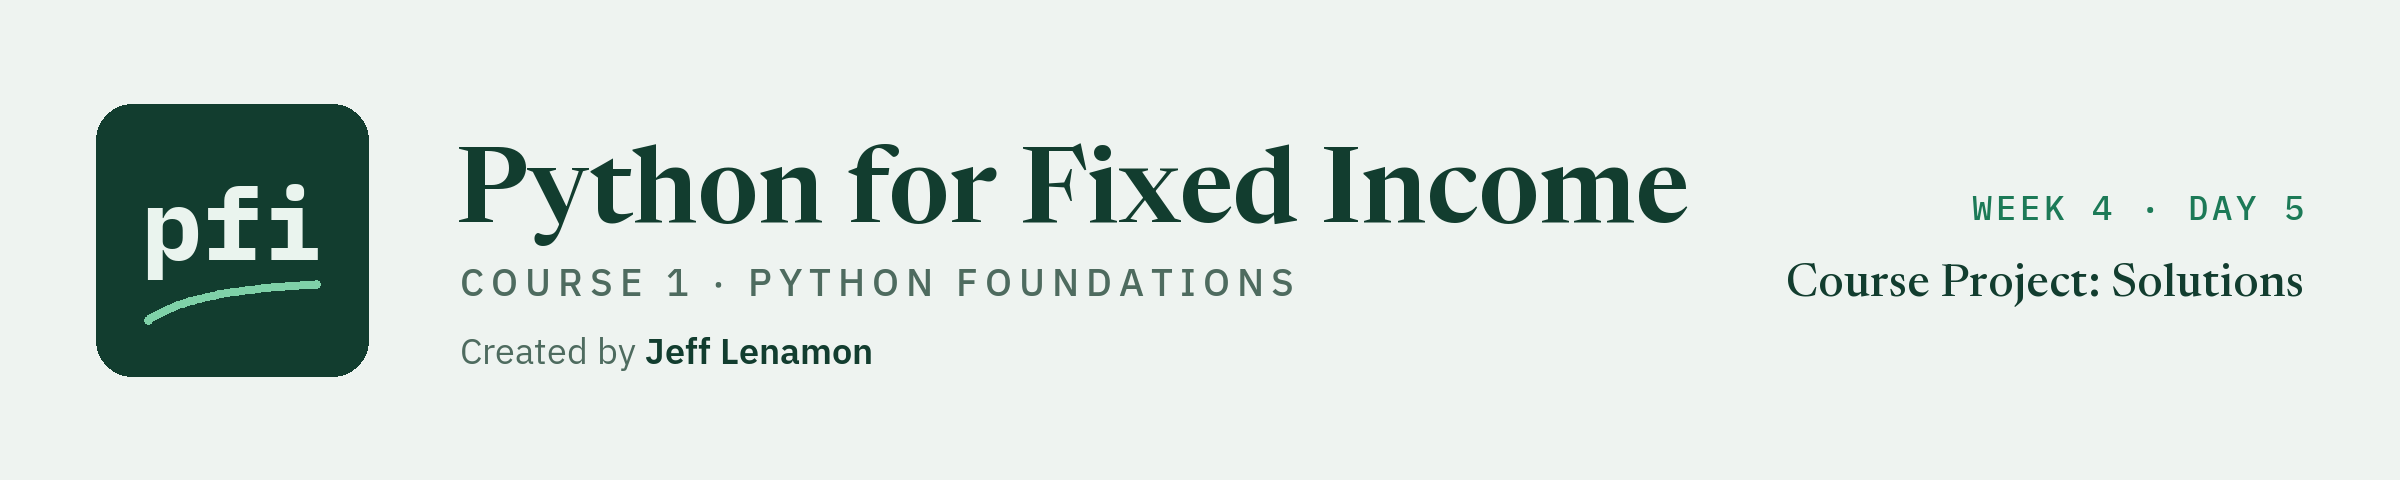

# Course Project - Solutions

Week 4, day 5. The worked version of the Course 1 project: every question answered with code, its output, and what the output shows. Write your own answers and your own conclusion first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day5/course1_project_solutions.ipynb)

## The brief

### The scenario

It is month end. You are the analyst on the credit desk, and the operations team has sent the holdings extract for 2026-10-30 with a cover note. The portfolio manager wants a written picture of the book before the month-end meeting: what is in it, where it is concentrated, whether the file can be trusted, and how the book differs from its benchmark.

This is the same desk and the same kind of extract as week 3, one month later. It is a new file. What was wrong with the September extract tells you nothing about what is wrong with this one. Run the routine, do not remember it.

Everything in the files is invented: the issuers, the tickers, the CUSIPs, the prices, and the positions. No name here refers to a real company.

### The cover note

```
To: Credit desk
From: Operations
Subject: Month-end holdings extract, as of 2026-10-30

The month-end extract is attached as project_holdings.csv.

Control totals for the book:
  Number of bonds:      206
  Total face:           507,250,000 dollars
  Total market value:   509,928,477.50 dollars

Market value is face times clean price plus accrued interest, divided by 100.
All positions are priced as of 2026-10-30.
Please tell us if the extract does not agree with these totals.
```

The note is also in the course repo as `data/project_cover_note.txt`.

### What to hand in

This notebook, completed and run from top to bottom, with:

* every code cell filled in and every decision written down;
* the function `clean_extract` of question 4.2, with its `assert` checks against the cover note;
* the Excel workbook of question 9.1, which the notebook writes, reads back, and deletes, so there is no second file to send;
* the AI-use log of question 9.2;
* the written conclusion of question 9.3.

### How long

The course map gives the project one day: week 4, day 5. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 structure, 2 data types, 3 testing the extract, 4 the fixes and the cleaning function |
| Second | 5 summary statistics, 6 one column at a time, 7 two or more columns |
| Third | 8 the desk's questions, 9 the workbook, the AI-use log, and the conclusion |

The first sitting ends with a table you trust and a function that rebuilds it. The other two describe the table.

### The rules

1. **Work in a copy.** `raw` is the file as it arrived and is never changed. Question 2.2 makes the working copy, `book`, and every fix is made to `book`.
2. **State every decision.** Before each fix, add a markdown cell that says what you are changing, in how many rows, and what evidence in the files supports it.
3. **Print the headline numbers before and after every fix.** The setup cell gives you `headline()` for that.
4. **Describe, never recommend.** Every sentence you write says what the data shows. Nothing recommends, ranks, or forecasts a bond, an issuer, or a sector.
5. **Charts are finished charts.** A title, a label on each axis, and the unit.
6. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

* Every earlier notebook of the course, and your own notes.
* The documentation of pandas, matplotlib, and seaborn.
* An AI assistant, used the way the course taught: read the code it gives you, predict what it will print, run it, and check the result against a number you worked out yourself or against a control total. An answer you cannot check is not finished. Nothing from an employer goes into an AI tool or into Colab. The course data is synthetic for that reason. Keep a note of what you ask as you go: question 9.2 asks for a log.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_3_2`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`.

The right answers are not written anywhere in this notebook. Each check holds a short code made from the right answer, and `check()` makes a code from your answer in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the number of places the question states before it is compared, so give your answer to at least that many places. Text is compared without regard to capitals or spaces at the ends.

A check tests the number. It does not test your reasoning, and charts and written answers have no check: each of those questions says what a good answer includes.

Your cleaning decisions change the numbers that follow. After question 4.1 there is a checkpoint cell that tests your cleaned table against the cover note and against the decisions the worked version made. Do not go on to section 5 until it passes. A different decision can be defensible. If you make one, say so in a markdown cell and expect the checks to disagree from there on.

Worked answers are in `course1_project_solutions.ipynb` in this folder. Open it after you have written your own conclusion.

## The data

Three files. Units: **`coupon` and `yield_pct` are in percent, `oas` is in basis points, `duration` is in years, `price` and `accrued` are per 100 of face, and `par_held`, `amount_outstanding`, and `market_value` are in dollars.**

**`project_holdings.csv`**: the extract. One row should be one bond the desk holds.

| Column | Meaning | Units |
| --- | --- | --- |
| `as_of_date` | the date the book is valued | year-month-day |
| `cusip` | the bond's identifier, nine characters | text |
| `ticker` | the issuer's ticker, four capital letters | text |
| `issuer` | the issuer's name | text |
| `sector` | the sector, a name from the benchmark's list | text |
| `rating` | the bond's rating, from AAA to CCC | text |
| `coupon` | annual coupon rate | percent |
| `maturity` | the date the bond repays | year-month-day |
| `price` | clean price | per 100 of face |
| `price_date` | the date of the price | year-month-day |
| `accrued` | accrued interest | per 100 of face |
| `yield_pct` | yield to maturity | percent |
| `oas` | option-adjusted spread, a whole number | basis points |
| `duration` | modified duration | years |
| `spread_duration` | spread duration, equal to the duration for these bonds | years |
| `dts` | duration times spread: spread duration times OAS, to one decimal place | years times basis points |
| `amount_outstanding` | face of the whole issue | dollars |
| `par_held` | face the desk holds | dollars |
| `market_value` | face held times (price plus accrued), divided by 100 | dollars |

**`ratings.csv`**: the rating scale, 18 rows. `rating`, `score` (1 for AAA up to 18 for CCC, so a higher score is a lower rating), `bucket` (the rating without its plus or minus), and `grade` (Investment Grade or High Yield).

**`benchmark.csv`**: the benchmark the book is measured against, 821 bonds. It has the same columns as the extract with two differences: there is no `par_held`, and there is a `weight_pct` column, the weight of each bond in the benchmark in percent. Its `market_value` is that of the whole issue. **The benchmark file is the September file, as of 2026-09-30.** The desk has not been sent an October one. In this project the book is compared with it by sector weights and by rating bucket weights only, and the conclusion says that the two files are a month apart.

## Setup

Run this cell first. It is complete: do not change it. It imports the libraries, loads the three files, stores the control totals from the cover note, and defines three helpers: `headline()`, which prints the headline numbers of a table, and `answer_text()` and `check()`, which mark your answers without showing the right ones. It prints the shapes of the rating scale and the benchmark. The shape of the extract is yours to find.

In [1]:
# hashlib makes the short codes that check() compares. os finds the data folder and deletes files.
import hashlib
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/project_holdings.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# raw is the extract exactly as it arrived. Nothing you write should change it.
raw = pd.read_csv(data_folder + 'project_holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')

# the control totals from the cover note
expected_bonds = 206
expected_face = 507_250_000
expected_value = 509_928_477.50


def headline(label, table):
    # the headline numbers, to print before and after every fix
    print(label)
    print(f'   rows: {len(table):,}')
    print(f"   face: {table['par_held'].sum():,} dollars")
    print(f"   market value: {table['market_value'].sum():,.2f} dollars")
    print(f"   mean OAS: {table['oas'].mean():.2f} basis points")


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # a pair of numbers: each one in turn
        return ','.join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f'{number:.{places}f}'


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f'{label}: not attempted yet')
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f'{label}: not yet. The answer should be a number, a piece of text, or a pair of numbers')
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(f'{label}|{text}'.encode()).hexdigest()[:12]
    if found == code:
        print(f'{label}: correct')
    else:
        print(f'{label}: not yet. You have {answer}')


print(f'Loaded raw, ratings {ratings.shape}, and benchmark {benchmark.shape}')

Loaded raw, ratings (18, 4), and benchmark (821, 19)


## 1 The structure of the data

### 1.1 Rows and columns

Q. How many rows and columns does the extract have? Store the shape, a pair of numbers (rows, columns), in **answer_1_1**, and show the first five rows. In a sentence, say what one row of this file is.

In [2]:
# shape is a pair: (rows, columns)
answer_1_1 = raw.shape
print('Rows and columns:', answer_1_1)

raw.head()

Rows and columns: (209, 19)


,as_of_date,cusip,ticker,issuer,sector,rating,coupon,maturity,price,price_date,accrued,yield_pct,oas,duration,spread_duration,dts,amount_outstanding,par_held,market_value
0,2026-10-30,99080CAE8,BEZE,Bezane Finance,Financials,BBB-,7.000,2032-06-18,106.576,2026-10-30,2.567,5.620,149.0,4.545,4.545,677.2,1650000000,4000000,4365720.0
1,2026-10-30,99049XAE2,BEZH,Bezamyth Machinery,Industrials,B,8.125,2029-04-17,97.242,2026-10-30,0.293,9.402,554.0,2.171,2.171,1202.7,950000000,250000,243837.5
2,2026-10-30,99049XAE2,BEZH,Bezamyth Machinery,Industrials,B,8.125,2029-04-17,97.242,2026-10-30,0.293,9.402,554.0,2.171,2.171,1202.7,950000000,250000,243837.5
3,2026-10-30,99039NAC0,BEZL,Bezoquil Freight,Transportation,BB,5.125,2030-06-03,98.848,2026-10-30,2.093,5.481,151.0,3.169,3.169,478.5,850000000,1500000,1514115.0
4,2026-10-30,99039NAF3,BEZL,Bezoquil Freight,Transportation,BB,4.875,2035-11-15,93.286,2026-10-30,2.234,5.841,153.0,6.975,6.975,1067.2,300000000,3750000,3582000.0


* 209 rows and 19 columns. One row should be one bond the desk holds, valued on the as-of date.
* The cover note says 206 bonds. The file has 3 rows more than the book it describes, before a single value has been read.
* The 19 columns are those of the week 3 extract, in the same order, so week 3 code runs on this file.

In [3]:
check('Question 1.1', answer_1_1, '05e0296b84e8')

Question 1.1: correct


### 1.2 Identifiers and dates

Q. How many different as-of dates, CUSIPs, tickers, and issuer names are in the file? Store the number of different CUSIPs in **answer_1_2**.

In [4]:
# nunique() counts the different values in a column
print('As-of dates:', raw['as_of_date'].unique().tolist())

answer_1_2 = raw['cusip'].nunique()
print('Different CUSIPs:', answer_1_2, 'in', len(raw), 'rows')
print('Different tickers:', raw['ticker'].nunique())
print('Different issuer names:', raw['issuer'].nunique())

As-of dates: ['2026-10-30']
Different CUSIPs: 206 in 209 rows
Different tickers: 113
Different issuer names: 113


* One as-of date, 2026-10-30, as the cover note says.
* 206 different CUSIPs in 209 rows. 206 is the cover note's number of bonds, so some CUSIP is in the file more than once. Section 3 finds which.
* 113 tickers and 113 issuer names. One ticker per issuer, and the two counts agree.

In [5]:
check('Question 1.2', answer_1_2, 'd52f49f181ed')

Question 1.2: correct


## 2 Data types

### 2.1 The type of each column

Q. What type did pandas give each column? Count the columns held as numbers and store the count in **answer_2_1**. In a sentence, say which columns hold dates and what type they have.

In [6]:
print(raw.dtypes)

# select_dtypes('number') keeps the columns held as numbers, float64 and int64
answer_2_1 = len(raw.select_dtypes('number').columns)
print(f'Columns held as numbers: {answer_2_1}')

as_of_date                str
cusip                     str
ticker                    str
issuer                    str
sector                    str
rating                    str
coupon                float64
maturity                  str
price                 float64
price_date                str
accrued               float64
yield_pct             float64
oas                   float64
duration              float64
spread_duration       float64
dts                   float64
amount_outstanding      int64
par_held                int64
market_value          float64
dtype: object
Columns held as numbers: 11


* 11 columns are numbers: nine `float64` and two `int64`. The other eight are text, shown as `str`. Older versions of pandas print `object`.
* Three of the text columns are dates: `as_of_date`, `maturity`, and `price_date`. `read_csv` left them as text, as it did in week 3.
* `oas` is `float64`. The data dictionary says the OAS is a whole number of basis points, and in the week 3 file the same column was `int64`. A column of whole numbers that pandas reads as `float64` is worth a second look. Section 3 finds the reason.

In [7]:
check('Question 2.1', answer_2_1, '4c24a69566ad')

Question 2.1: correct


### 2.2 A working copy with real dates

Q. Make a working copy of `raw` called `book`, and convert its three date columns to dates. Count the dates that could not be read, over the three columns, and store the count in **answer_2_2**. Print the earliest and the latest value of each date column.

From here on every fix is made to `book`, and `raw` stays as it arrived.

In [8]:
# book is the working copy. raw is not changed again.
book = raw.copy()

answer_2_2 = 0
for column in ['as_of_date', 'maturity', 'price_date']:
    # errors='coerce' turns text that is not a date into a missing date, so count those straight away
    book[column] = pd.to_datetime(book[column], format='%Y-%m-%d', errors='coerce')
    unread = book[column].isna().sum()
    answer_2_2 = answer_2_2 + unread
    print(column, '- type:', book[column].dtype, ' not read:', unread,
          ' earliest:', book[column].min().date(), ' latest:', book[column].max().date())

as_of_date - type: datetime64[us]  not read: 0  earliest: 2026-10-30  latest: 2026-10-30
maturity - type: datetime64[us]  not read: 0  earliest: 2019-10-21  latest: 2056-07-24
price_date - type: datetime64[us]  not read: 0  earliest: 2026-10-30  latest: 2026-10-30


* All three columns are dates now, and 0 values failed to convert.
* `as_of_date` and `price_date` each run from 2026-10-30 to 2026-10-30: one date.
* `maturity` runs from 2019-10-21 to 2056-07-24. The earliest maturity is seven years before the as-of date. A bond that has matured is not a holding. Section 3 tests it as a rule.

In [9]:
check('Question 2.2', answer_2_2, '08e885e49d35')

Question 2.2: correct


## 3 Data quality: test the extract

There is no list of what is wrong with this file. There is the cover note, and there are the rules the desk expects every extract to meet.

**The brief: test this extract against its cover note and the rules below. Fix what is an error, flag what you cannot fix, keep what is real.**

| Rule | What the desk expects of an extract |
| --- | --- |
| 1 | One row for each bond held. No row is a copy of another |
| 2 | Identifiers are well formed and unique. A CUSIP is nine characters, each a capital letter or a digit, and appears once |
| 3 | The face held is positive |
| 4 | The maturity is after the as-of date |
| 5 | Market value equals face times (price plus accrued), divided by 100, to within 1 dollar |
| 6 | Sector names are the names in the benchmark's list |
| 7 | No number is missing |

The cover note adds claims of its own: the three control totals, and that every position is priced as of 2026-10-30.

Section 3 is for finding. Each question tests one rule or one claim and asks how many rows fail it. **Count on `book` as question 2.2 left it, and fix nothing yet.** A rule that every row passes is a result too, and it goes in your write-up beside the rules that failed. Section 4 is for deciding and fixing.

Under some questions there is a closed block that starts "Stuck after trying?". It holds the decision that the checkpoint in section 4 expects for one kind of problem. Leave it closed until you have made your own decision. Open it if the checkpoint disagrees with you and you cannot see why.

### 3.1 The file against the cover note

Q. Print the headline numbers of the extract as received. Then print the difference between the file and the cover note, file less cover note, for the number of rows, the total face, and the total market value. Store the difference in rows in **answer_3_1**. In a sentence, say what the three differences suggest.

In [10]:
headline('As received', raw)

# each figure less the cover note's
answer_3_1 = len(raw) - expected_bonds
print(f'Rows less cover note: {answer_3_1}')
print(f"Face less cover note: {raw['par_held'].sum() - expected_face:,} dollars")
print(f"Market value less cover note: {raw['market_value'].sum() - expected_value:,.2f} dollars")

As received
   rows: 209
   face: 507,000,000 dollars
   market value: 516,229,847.50 dollars
   mean OAS: 192.18 basis points
Rows less cover note: 3
Face less cover note: -250,000 dollars
Market value less cover note: 6,301,370.00 dollars


* As received: 209 rows, 507,000,000 dollars of face, 516,229,847.50 dollars of market value, and a mean OAS of 192.18 basis points.
* 3 rows too many, and 6,301,370.00 dollars of market value too much. The face is 250,000 dollars too little.
* The differences do not point the same way. Extra rows would add face as well as market value, and the face is short. One problem cannot do both, so there are at least two.

In [11]:
check('Question 3.1', answer_3_1, 'f3aa83b30526')

Question 3.1: correct


### 3.2 Rule 1: one row for each bond

Q. How many rows of `book` are an exact copy of an earlier row? Store the count in **answer_3_2**. Show each copy next to the row it repeats, and print the face and the market value that the copies carry.

In [12]:
# duplicated() marks a row that matches an earlier row in every column
answer_3_2 = book.duplicated().sum()
print(f'Rows that repeat an earlier row: {answer_3_2}')

# what the copies carry
print(f"Face in the copies: {book.loc[book.duplicated(), 'par_held'].sum():,} dollars")
print(f"Market value in the copies: {book.loc[book.duplicated(), 'market_value'].sum():,.2f} dollars")

# keep=False marks the first appearance as well as the copy
book.loc[book.duplicated(keep=False), ['cusip', 'ticker', 'issuer', 'par_held', 'market_value']]

Rows that repeat an earlier row: 3
Face in the copies: 6,250,000 dollars
Market value in the copies: 6,301,370.00 dollars


,cusip,ticker,issuer,par_held,market_value
1,99049XAE2,BEZH,Bezamyth Machinery,250000,243837.5
2,99049XAE2,BEZH,Bezamyth Machinery,250000,243837.5
175,99085HAA0,TROR,Tromazor Resources,2250000,2244870.0
176,99085HAA0,TROR,Tromazor Resources,2250000,2244870.0
186,99006GAC4,VYRH,Veyrholt Health,3750000,3812662.5
187,99006GAC4,VYRH,Veyrholt Health,3750000,3812662.5


* 3 rows are exact copies of an earlier row.
* The row labels show where they are: each copy is directly below its original, at rows 2, 176, and 187. In the week 3 file the copies were the last rows of the file. A check that only looked at the end of this file would find nothing.
* The copies carry 6,250,000 dollars of face and 6,301,370.00 dollars of market value. The second figure is the market value difference from the cover note, to the dollar.
* In Excel: `=COUNTIF($B$2:$B$210, B2) > 1` filled down shows which rows repeat. The CUSIP is in column B.

In [13]:
check('Question 3.2', answer_3_2, '728beb562550')

Question 3.2: correct


**The decision the checkpoint expects.** Remove exact duplicate rows, keeping the first of each, and renumber the rows.

### 3.3 Rule 2: identifiers

Q. Test the shape of every CUSIP in `book` with a regular expression: nine characters, each a capital letter or a digit, and nothing else. Store the number of rows whose CUSIP fails the test in **answer_3_3a**.

Then test the other half of the rule. Is any CUSIP in the file with two different sets of values? Is every CUSIP also in `benchmark.csv`? Store the number of rows whose CUSIP is **not** found in the benchmark in **answer_3_3b**.

In [14]:
# fullmatch() is True when the whole value fits the pattern: nine characters, each a capital letter or a digit
good_shape = book['cusip'].str.fullmatch(r'[A-Z0-9]{9}')
answer_3_3a = (~good_shape).sum()
print(f'CUSIPs that fail the shape test: {answer_3_3a}')

# a CUSIP that is there twice with different values would survive the removal of exact copies
without_copies = book.drop_duplicates()
print(f"CUSIPs repeated with different values: {without_copies['cusip'].duplicated().sum()}")

# isin() is True where the CUSIP is one of the benchmark's
in_benchmark = book['cusip'].isin(benchmark['cusip'])
answer_3_3b = (~in_benchmark).sum()
print(f'Rows whose CUSIP is not in the benchmark: {answer_3_3b}')

CUSIPs that fail the shape test: 0
CUSIPs repeated with different values: 0
Rows whose CUSIP is not in the benchmark: 0


* 0 CUSIPs fail the shape test. Every one is nine capital letters and digits.
* 0 CUSIPs are repeated with different values. The only repeats are the exact copies of question 3.2.
* 0 rows have a CUSIP that the benchmark does not list. Every bond in the extract can be looked up in the second file.
* Every test here passed. A clean result is a result: it goes in the write-up with the tests that were run.
* The pattern is the one from week 4, day 2. `fullmatch` is what makes it a test of the whole value: a ten-character value that starts with nine good characters fails.

In [15]:
check('Question 3.3 shape', answer_3_3a, '08454d23b633')
check('Question 3.3 benchmark', answer_3_3b, 'dcbc94df3ff7')

Question 3.3 shape: correct
Question 3.3 benchmark: correct


### 3.4 Rule 3: the face held

Q. How many rows of `book` break rule 3? Store the count in **answer_3_4**, and show the rows with their price, accrued interest, face, and market value. Do not fix anything yet.

In [16]:
# True marks a row that breaks the rule
bad_face = book['par_held'] <= 0

answer_3_4 = bad_face.sum()
print(f'Rows with a face held of zero or less: {answer_3_4}')
print(f"Face in those rows: {book.loc[bad_face, 'par_held'].sum():,} dollars")

book.loc[bad_face, ['cusip', 'ticker', 'price', 'accrued', 'par_held', 'market_value']]

Rows with a face held of zero or less: 2
Face in those rows: -3,250,000 dollars


,cusip,ticker,price,accrued,par_held,market_value
138,99032GAB4,QUEL,102.225,1.576,-1250000,1297512.5
190,99042QAA2,VYRR,100.994,1.666,-2000000,2053200.0


* 2 rows have a negative face: QUEL with -1,250,000 dollars and VYRR with -2,000,000. Both have a positive market value.
* The two add up to -3,250,000 dollars. Reversing the sign of both would add 6,500,000 dollars of face.
* That fits question 3.1. The copies of question 3.2 put 6,250,000 dollars of face too much into the file, and these two rows take 6,500,000 out. The net is the 250,000 dollars by which the file is short of the cover note.

In [17]:
check('Question 3.4', answer_3_4, '2c4fa0f7092d')

Question 3.4: correct


**The decision the checkpoint expects.** Where the face held is negative and the market value in the same row is the figure that the positive amount gives, the sign of the face is the error. The face becomes the positive amount, and the market value column is left alone.

### 3.5 Rule 4: the maturity

Q. How many rows of `book` break rule 4? Store the count in **answer_3_5**, and show the rows with their coupon, maturity, and duration. Do not fix anything yet.

In [18]:
# a maturity on or before the as-of date
bad_maturity = book['maturity'] <= book['as_of_date']

answer_3_5 = bad_maturity.sum()
print(f'Rows with a maturity on or before the as-of date: {answer_3_5}')

book.loc[bad_maturity, ['cusip', 'ticker', 'coupon', 'maturity', 'duration', 'par_held']]

Rows with a maturity on or before the as-of date: 1


,cusip,ticker,coupon,maturity,duration,par_held
148,99046UAD3,SKEN,9.25,2019-10-21,2.55,1000000


* 1 row: SKEN `99046UAD3`, with a maturity of 2019-10-21 and a duration of 2.55 years.
* A bond that matured seven years ago is not a holding, and it has no duration. The duration says the bond has about three years left, so the maturity is the column that is wrong.
* The rule needs no judgement. Deciding what the right date is does, and that is section 4.

In [19]:
check('Question 3.5', answer_3_5, '2493672bd5bb')

Question 3.5: correct


**The decision the checkpoint expects.** A maturity that is not after the as-of date is replaced with the maturity of the same CUSIP in `benchmark.csv`, after checking that the ticker and the coupon of that CUSIP agree in the two files.

### 3.6 Rule 5: does the file agree with itself?

Q. Work out face times (price plus accrued), divided by 100, for every row of `book`, and compare it with the `market_value` column. Store the number of rows where the two differ by more than 1 dollar in **answer_3_6**, and show those rows. For each one, which column looks wrong? Do not fix anything yet.

In [20]:
# market value worked out from three other columns
worked_out = book['par_held'] * (book['price'] + book['accrued']) / 100

# the gap between that and the market_value column. abs() drops the sign.
gap = (worked_out - book['market_value']).abs()
no_tie = gap > 1

answer_3_6 = no_tie.sum()
print(f'Rows that do not tie out: {answer_3_6}')
print(f'Largest gap in the other rows: {gap[~no_tie].max():,.2f} dollars')
print(f"Prices in the other rows: from {book.loc[~no_tie, 'price'].min()} to {book.loc[~no_tie, 'price'].max()}")

book.loc[no_tie, ['cusip', 'ticker', 'rating', 'coupon', 'yield_pct', 'price', 'accrued', 'par_held', 'market_value']]

Rows that do not tie out: 5
Largest gap in the other rows: 0.00 dollars
Prices in the other rows: from 63.522 to 126.427


,cusip,ticker,rating,coupon,yield_pct,price,accrued,par_held,market_value
138,99032GAB4,QUEL,BBB-,6.375,6.027,102.22500,1.576,-1250000,1297512.5
174,99093PAB0,TROE,BB+,6.375,5.791,1.01860,2.639,2750000,2873722.5
190,99042QAA2,VYRR,AA-,4.875,4.472,100.99400,1.666,-2000000,2053200.0
200,99036KAA3,XANL,CCC,10.625,10.389,1.01346,2.833,3250000,3385817.5
203,99104AAD6,YARN,A-,4.375,4.937,9824.30000,0.304,1250000,1231837.5


* 5 rows do not tie out. In the other 204 the largest gap is 0.00 dollars.
* Two of the five are the rows with a negative face from question 3.4: QUEL and VYRR.
* The other three have a price that is far from every other price in the file: 1.0186 for TROE, 1.01346 for XANL, and 9,824.3 for YARN. The prices of the 204 rows that tie out run from 63.522 to 126.427.
* None of the three would break a rule such as "a price is above zero", because a price of 1.0186 is above zero. A rule about one column catches the impossible. A rule that ties columns together catches the inconsistent.
* In Excel: `=R2 * (I2 + K2) / 100 - S2` in a helper column, with the face in column R, the price in column I, the accrued interest in column K, and the market value in column S.

In [21]:
check('Question 3.6', answer_3_6, 'e9fef2de8fb0')

Question 3.6: correct


**The decision the checkpoint expects.** A row can fail this rule for more than one reason, so look at which column is out of line with the rest of the file. Where the face is the cause, the decision under question 3.4 settles it. Where the price is the cause, work out the price that the market value, the face, and the accrued interest imply. If the price in the file is that price with the decimal point in the wrong place, put it back into units of per 100 of face, rounded to 3 decimal places. The market value column is left alone.

### 3.7 Rule 6: sector names

Q. List every value of `sector` in `book` with its count, and list the sector names the benchmark uses. Store the number of rows of `book` whose sector is **not** one of the benchmark's names, exactly as written there, in **answer_3_7**. Print the values that fail in a way that shows any space at either end.

In [22]:
# every different value and how often it appears
print(book['sector'].value_counts())

# the names the benchmark uses
benchmark_sectors = sorted(set(benchmark['sector']))
print(f'Sector names in the benchmark: {len(benchmark_sectors)}')
print(f"Different sector values in the extract: {book['sector'].nunique()}")

# isin() is True where the value is one of the benchmark's names
off_list = ~book['sector'].isin(benchmark_sectors)
answer_3_7 = off_list.sum()
print(f'Rows whose sector is not a benchmark name: {answer_3_7}')

# tolist() prints each value in quotes, so that the spaces show
print(book.loc[off_list, 'sector'].tolist())

sector
Financials         27
Materials          26
Telecom            24
Consumer           23
Transportation     21
Health Care        19
Industrials        18
Energy             16
Utilities          13
Technology         13
utilities           1
MATERIALS           1
Transportation      1
 consumer           1
industrials         1
TECHNOLOGY          1
Energy              1
 industrials        1
telecom             1
Name: count, dtype: int64
Sector names in the benchmark: 10
Different sector values in the extract: 19
Rows whose sector is not a benchmark name: 9
['utilities', 'MATERIALS', 'Transportation ', ' consumer', 'industrials', 'TECHNOLOGY', 'Energy ', ' industrials', 'telecom']


* The benchmark has 10 sector names. The extract has 19 different values in the column.
* 9 rows hold a value that is not a benchmark name, and each of the nine is at the bottom of the list with a count of 1: `utilities`, `MATERIALS`, `TECHNOLOGY`, `telecom`, and so on.
* Two of them look right in the list and are not: `'Transportation '` and `'Energy '` end in a space, which only the quotes of `tolist()` show. Two more start with a space.
* Each of the nine is a benchmark name in another case or with a stray space. No value is a sector the benchmark does not have.

In [23]:
check('Question 3.7', answer_3_7, '985e649e999c')

Question 3.7: correct


**The decision the checkpoint expects.** A sector value that differs from a benchmark name only in upper and lower case, or in spaces at either end, is that sector. Tidy every value to the benchmark's spelling: strip the spaces and give each word a capital. Then check that the set of names in the book equals `set(benchmark['sector'])`, because a later join by sector name would leave out any name that does not match.

### 3.8 Rule 7: missing numbers

Q. How many values are missing in each column of `book`? Store the total number of missing cells in **answer_3_8a**, and show the rows that have one. What is the market value of those rows as a percent of the market value on the cover note? Store it, rounded to 2 decimal places, in **answer_3_8b**.

Then, without changing `book`, print what dropping those rows would do to the row count and the market value. In a sentence, say whether the gaps share a sector, an issuer, or a rating.

In [24]:
# isna() is True for each missing cell, and sum() counts them by column
missing = book.isna().sum()
print(missing[missing > 0])

answer_3_8a = missing.sum()
print(f'Missing cells in the whole table: {answer_3_8a}')

# the rows with a gap in any column
incomplete = book[book.isna().any(axis=1)]

answer_3_8b = round(incomplete['market_value'].sum() / expected_value * 100, 2)
print(f"Market value of the rows: {incomplete['market_value'].sum():,.2f} dollars")
print(f'Share of the cover note market value: {answer_3_8b} percent')

# what dropping them would do. dropna() returns a new table, and book is not changed.
dropped = book.dropna()
print(f'Dropped: {len(book)} rows would become {len(dropped)}')
print(f"Mean OAS as it stands: {book['oas'].mean():.2f} basis points over {book['oas'].count()} of {len(book)} rows")

incomplete[['cusip', 'ticker', 'issuer', 'sector', 'rating', 'spread_duration', 'dts', 'market_value']]

oas    4
dtype: int64
Missing cells in the whole table: 4
Market value of the rows: 16,957,307.50 dollars
Share of the cover note market value: 3.33 percent
Dropped: 209 rows would become 205
Mean OAS as it stands: 192.18 basis points over 205 of 209 rows


,cusip,ticker,issuer,sector,rating,spread_duration,dts,market_value
82,99078AAE6,HESA,Heskundra Retail,Consumer,A-,6.685,715.3,4886182.5
96,99087JAC0,KRIX,Krilellix Networks,Telecom,BBB-,4.631,889.2,4682012.5
99,99114KAA8,LORE,Lorvane Systems,Technology,BB-,1.810,689.6,2753162.5
147,99079BAC7,RULR,Rulvazor Utilities,Utilities,A+,7.753,441.9,4635950.0


* One column has gaps: `oas`, with 4. The other 18 columns are complete.
* This is why `oas` was `float64` in question 2.1. A column of whole numbers with an empty cell cannot be `int64`, because `NaN` is a decimal value, so pandas reads the whole column as decimals.
* Four bonds of four issuers, HESA, KRIX, LORE, and RULR, with 16,957,307.50 dollars of market value, 3.33 percent of the cover note's figure. No pattern: four sectors, Consumer, Telecom, Technology, and Utilities, and four ratings, A-, BBB-, BB-, and A+.
* Dropping them would take 209 rows to 205 and remove four bonds the desk owns because one cell in each is empty.
* Left alone, the mean OAS is 192.18 basis points, and it is a mean of 205 rows presented as a mean of 209. A missing number drops out of every sum and mean without a message.
* Every other column of the four rows is filled in, including `spread_duration` and `dts`.
* In Excel: `=COUNTBLANK(M2:M210)` on the OAS column, which returns 4.

In [25]:
check('Question 3.8 missing cells', answer_3_8a, '817e19661fd9')
check('Question 3.8 share', answer_3_8b, 'e3f4ef2ffa88', places=2)

Question 3.8 missing cells: correct
Question 3.8 share: correct


**The decision the checkpoint expects.** No row is dropped for a missing value. The data dictionary says `dts` is spread duration times OAS, so a missing OAS can be worked out from two columns of its own row: `dts` divided by `spread_duration`, rounded to a whole basis point. Test that rule on the rows where the OAS is present before using it. Once the gaps are filled, make the column whole numbers again.

### 3.9 The cover note: price dates

Q. The cover note says every position is priced as of the as-of date. Count the rows of `book` whose `price_date` is not the `as_of_date`, and store the count in **answer_3_9**.

In [26]:
# the rows whose price is dated on another day than the as-of date
answer_3_9 = (book['price_date'] != book['as_of_date']).sum()
print(f'Rows priced on another date: {answer_3_9}')
print(f"Price dates run from {book['price_date'].min().date()} to {book['price_date'].max().date()}")

Rows priced on another date: 0
Price dates run from 2026-10-30 to 2026-10-30


* 0 rows. Every price is dated 2026-10-30, as the cover note says. The stale prices of the week 3 file are not in this one.
* The cover note made the claim and the file was tested against it. A claim that has been checked is worth more in the write-up than one that has been copied.

In [27]:
check('Question 3.9', answer_3_9, '2bdb851b27d6')

Question 3.9: correct


### 3.10 Other values that cannot be right

Q. The seven rules are the desk's minimum. Test these six as well, and print the number of rows of `book` that break each:

* a price of zero or less
* a coupon of zero or less
* a duration of zero or less
* a face held above the amount outstanding
* a rating that is not on the rating scale
* a ticker with a space at either end or a lower-case letter

Store the total number of breaks, added over the six tests, in **answer_3_10**.

In [28]:
# one mask for each test. True marks a row that breaks it.
bad_price = book['price'] <= 0
bad_coupon = book['coupon'] <= 0
bad_duration = book['duration'] <= 0
too_much_face = book['par_held'] > book['amount_outstanding']
off_scale = ~book['rating'].isin(ratings['rating'])
untidy_ticker = book['ticker'] != book['ticker'].str.strip().str.upper()

print(f'Price of zero or less: {bad_price.sum()}')
print(f'Coupon of zero or less: {bad_coupon.sum()}')
print(f'Duration of zero or less: {bad_duration.sum()}')
print(f'Face held above the amount outstanding: {too_much_face.sum()}')
print(f'Rating not on the scale: {off_scale.sum()}')
print(f'Untidy ticker: {untidy_ticker.sum()}')

answer_3_10 = (bad_price.sum() + bad_coupon.sum() + bad_duration.sum()
               + too_much_face.sum() + off_scale.sum() + untidy_ticker.sum())
print(f'Breaks in total: {answer_3_10}')

Price of zero or less: 0
Coupon of zero or less: 0
Duration of zero or less: 0
Face held above the amount outstanding: 0
Rating not on the scale: 0
Untidy ticker: 0
Breaks in total: 0


* 0 breaks. All six tests pass on every row.
* The ticker problem of the week 3 file is not in this one. What was wrong with September's extract said nothing about October's.
* These go in the write-up as checked and found clean.

In [29]:
check('Question 3.10', answer_3_10, '9f5ca9fed4e4')

Question 3.10: correct


## 4 Data quality: decide, fix, and package

### 4.1 Decide and fix

Q. Go back over every row that failed a test in section 3 and sort it into one of three kinds:

* **an error you can fix**, because the files hold the evidence for the right value;
* **an error you cannot fix**, which is flagged and reported;
* **a real value**, which is kept.

For each fix, add a markdown cell that states the decision: what you are changing, in how many rows, and the evidence. Make the fix to `book`, and print the headline numbers before and after it.

When the fixes are made, run the tests of questions 3.2 to 3.10 again on `book`. Store the total number of rows that still fail any of them in **answer_4_1**.

**Decision 1.** Remove the 3 repeated rows, keeping the first of each. Evidence: they match an earlier row in all 19 columns, and their market value is exactly the excess over the control total.

In [30]:
headline('Before', book)

# drop_duplicates() keeps the first appearance. reset_index(drop=True) renumbers the rows from 0.
book = book.drop_duplicates().reset_index(drop=True)

headline('After', book)
print(f"Every CUSIP appears once: {book['cusip'].is_unique}")
print(f"Face less cover note: {book['par_held'].sum() - expected_face:,} dollars")
print(f"Market value less cover note: {book['market_value'].sum() - expected_value:,.2f} dollars")

Before
   rows: 209
   face: 507,000,000 dollars
   market value: 516,229,847.50 dollars
   mean OAS: 192.18 basis points
After
   rows: 206
   face: 500,750,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
Every CUSIP appears once: True
Face less cover note: -6,500,000 dollars
Market value less cover note: 0.00 dollars


* 209 rows became 206, the cover note's number. The market value went from 516,229,847.50 to 509,928,477.50 dollars and now matches the control total with a difference of 0.00.
* The mean OAS moved from 192.18 to 190.21 basis points.
* The face went from 507,000,000 to 500,750,000 dollars, and its difference from the cover note grew from -250,000 to -6,500,000. Removing one problem uncovered the size of another: the extra face in the copies had been hiding most of a shortfall somewhere else.
* In Excel: Data, Remove Duplicates, on a copy of the sheet.

**Decision 2.** Replace the sector of every row with its tidy version. Evidence: each of the 9 values that is not a benchmark name becomes one once the spaces are stripped and the capitals set, and no new name appears.

In [31]:
# Industrials as the file has it: three spellings, three groups
before = book.groupby('sector')['market_value'].sum()
print(f"Before - different sectors: {book['sector'].nunique()}  Industrials market value: {before.loc['Industrials']:,.2f}")

# no spaces at the ends, a capital at the start of each word
book['sector'] = book['sector'].str.strip().str.title()

after = book.groupby('sector')['market_value'].sum()
print(f"After  - different sectors: {book['sector'].nunique()}  Industrials market value: {after.loc['Industrials']:,.2f}")
print(f"Difference: {after.loc['Industrials'] - before.loc['Industrials']:,.2f} dollars")

# the tidy names must be the benchmark's names, or a later join by sector would leave rows out
print(f"Same sector names as the benchmark: {set(book['sector']) == set(benchmark['sector'])}")

headline('After', book)

Before - different sectors: 19  Industrials market value: 41,916,605.00
After  - different sectors: 10  Industrials market value: 50,287,460.00
Difference: 8,370,855.00 dollars
Same sector names as the benchmark: True
After
   rows: 206
   face: 500,750,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points


* 19 sector values became 10, and 9 values changed. No row was added or removed. The ten names are the ten the benchmark uses.
* Grouped on the column as received, Industrials was 41,916,605.00 dollars. Tidied, it is 50,287,460.00. A sector report built on the raw column would have understated Industrials by 8,370,855.00 dollars and shown two extra one-bond sectors, with no error raised.
* The headline numbers do not move: 206 rows, 500,750,000 dollars of face, 509,928,477.50 of market value, 190.21 basis points. None of them is grouped by sector. A fix can matter for one report and not for another.
* In Excel: `=PROPER(TRIM(E2))` in a helper column, with the sector in column E.

**The face.** In each of the two rows either the face or the market value has the wrong sign. Which?

In [32]:
# the rows were renumbered when the copies were removed, so mark the rows again
bad_face = book['par_held'] <= 0

# what the market value would be with the sign of the face removed
positive_face = book.loc[bad_face, 'par_held'].abs()
with_positive_face = positive_face * (book.loc[bad_face, 'price'] + book.loc[bad_face, 'accrued']) / 100

print(f"Market value in the file: {book.loc[bad_face, 'market_value'].tolist()}")
print(f'Worked out from the positive face: {with_positive_face.round(2).tolist()}')

Market value in the file: [1297512.5, 2053200.0]
Worked out from the positive face: [1297512.5, 2053200.0]


* 1,297,512.5 and 2,053,200.0 dollars both ways. The market value in the file is the one the positive face gives, to the cent.

**Decision 3.** Make the face of the 2 rows positive. Evidence: the market value column agrees with the positive amount exactly, and the two corrections add up to the 6,500,000 dollars by which the face is short of the cover note.

In [33]:
headline('Before', book)

# abs() removes the sign
book.loc[bad_face, 'par_held'] = book.loc[bad_face, 'par_held'].abs()

headline('After', book)
print(f"Face less cover note: {book['par_held'].sum() - expected_face:,} dollars")

Before
   rows: 206
   face: 500,750,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
After
   rows: 206
   face: 507,250,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
Face less cover note: 0 dollars


* The face went from 500,750,000 to 507,250,000 dollars and now matches the cover note with a difference of 0. Rows, market value, and mean OAS are unchanged.

**The price.** In the three rows that still do not tie out, the price and the market value disagree. The market value, the face, and the accrued interest together imply a price.

In [34]:
# the price that the other three columns imply: market value over face, times 100, less accrued
implied_price = book['market_value'] / book['par_held'] * 100 - book['accrued']

# the three rows whose price is far outside the range of the rest
wrong_price = (book['price'] < 10) | (book['price'] > 1000)

evidence = book.loc[wrong_price, ['cusip', 'ticker', 'coupon', 'yield_pct', 'price']].copy()
evidence['implied_price'] = implied_price[wrong_price].round(3)
print(evidence)

         cusip ticker  coupon  yield_pct       price  implied_price
173  99093PAB0   TROE   6.375      5.791     1.01860        101.860
197  99036KAA3   XANL  10.625     10.389     1.01346        101.346
200  99104AAD6   YARN   4.375      4.937  9824.30000         98.243


* The implied prices are 101.86, 101.346, and 98.243. The prices in the file are 1.0186, 1.01346, and 9,824.3: the same digits with the decimal point two places out. Two were entered at a hundredth of the price and one at a hundred times it.
* The other columns agree with the implied prices. TROE has a 6.375 percent coupon and a 5.791 percent yield: a yield below the coupon goes with a price above 100, and 101.86 is. YARN has a 4.375 percent coupon and a 4.937 percent yield, and 98.243 is below 100.

**Decision 4.** Multiply the 2 prices below 10 by 100 and divide the 1 price above 1,000 by 100. Evidence: each corrected price reproduces the market value in the file to the cent and is on the right side of 100 for its coupon and yield. The market value column is left alone.

In [35]:
too_low = book['price'] < 10
too_high = book['price'] > 1000

headline('Before', book)
print(f"   mean price: {book['price'].mean():.3f}  median price: {book['price'].median():.3f}")

# round(3) keeps three decimal places, like the rest of the column
book.loc[too_low, 'price'] = (book.loc[too_low, 'price'] * 100).round(3)
book.loc[too_high, 'price'] = (book.loc[too_high, 'price'] / 100).round(3)

headline('After', book)
print(f"   mean price: {book['price'].mean():.3f}  median price: {book['price'].median():.3f}")

Before
   rows: 206
   face: 507,250,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
   mean price: 145.043  median price: 99.389
After
   rows: 206
   face: 507,250,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
   mean price: 98.806  median price: 99.474


* The four headline numbers do not change, because none of them uses the price. The mean price does: 145.043 as received and 98.806 corrected. One price of 9,824.3 among 206 was enough to move the mean by about 46 points. The median moved from 99.389 to 99.474, less than a tenth of a point. A mean takes in the full size of an error and a median mostly ignores it.

**The maturity.** The extract cannot say what the maturity should be. The benchmark file lists the same bond.

In [36]:
# mark the row again, on the renumbered table
bad_maturity = book['maturity'] <= book['as_of_date']

# the CUSIP of the row, and the same CUSIP in the benchmark
bad_cusip = book.loc[bad_maturity, 'cusip'].iloc[0]
benchmark_row = benchmark[benchmark['cusip'] == bad_cusip]

print('In the extract:')
print(book.loc[bad_maturity, ['cusip', 'ticker', 'coupon', 'maturity', 'duration']])
print('In the benchmark:')
print(benchmark_row[['cusip', 'ticker', 'coupon', 'maturity']])

In the extract:
         cusip ticker  coupon   maturity  duration
147  99046UAD3   SKEN    9.25 2019-10-21      2.55
In the benchmark:
         cusip ticker  coupon    maturity
237  99046UAD3   SKEN    9.25  2029-10-21


* The benchmark has the same CUSIP, the same ticker, and the same 9.25 percent coupon, with a maturity of 2029-10-21: the same month and day, ten years later.
* A maturity in October 2029 is three years after the as-of date, which fits the duration of 2.55 years in the extract. A maturity in 2019 fits nothing.

**Decision 5.** Replace the maturity of the 1 row with the benchmark's, 2029-10-21. Evidence: the same CUSIP in a second file, and a duration in the extract that agrees with it.

In [37]:
headline('Before', book)

# the benchmark's maturity is text, so make it a date before storing it
book.loc[bad_maturity, 'maturity'] = pd.Timestamp(benchmark_row['maturity'].iloc[0])

headline('After', book)
print(f"Maturity of {bad_cusip} is now {book.loc[bad_maturity, 'maturity'].iloc[0].date()}")
print(f"Earliest maturity in the book: {book['maturity'].min().date()}")

Before
   rows: 206
   face: 507,250,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
After
   rows: 206
   face: 507,250,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
Maturity of 99046UAD3 is now 2029-10-21
Earliest maturity in the book: 2027-10-02


* The headline numbers are unchanged. The earliest maturity in the book is now 2027-10-02, after the as-of date.

**The missing OAS.** Test the rule before trusting it.

In [38]:
# the OAS that DTS and spread duration imply, for every row
worked_out_oas = (book['dts'] / book['spread_duration']).round()

# notna() is True where a value is present
present = book['oas'].notna()

print(f'Rows with an OAS: {present.sum()}')
print(f"Of those, rows where the rule gives a different OAS: {(worked_out_oas[present] != book.loc[present, 'oas']).sum()}")
print(f'What the rule gives for the four gaps: {worked_out_oas[~present].tolist()}')

Rows with an OAS: 202
Of those, rows where the rule gives a different OAS: 0
What the rule gives for the four gaps: [107.0, 192.0, 381.0, 57.0]


* In all 202 rows that have an OAS, DTS divided by spread duration, rounded, is the OAS in the file. The rule is right 202 times out of 202.
* For the four gaps it gives 107, 192, 381, and 57 basis points.

**Decision 6.** Fill the 4 missing OAS values with DTS divided by spread duration, rounded to a whole basis point. Evidence: the rule reproduces the OAS in every one of the 202 complete rows. These are worked out from the file, not guessed, and they are listed in the write-up for the operations team to confirm.

In [39]:
headline('Before', book)

# fillna() given a column fills each gap from the same row of that column
book['oas'] = book['oas'].fillna(worked_out_oas)

# no gaps are left, so the column can hold whole numbers again
book['oas'] = book['oas'].astype(int)

headline('After', book)
print(f"Missing cells left: {book.isna().sum().sum()}  type of oas: {book['oas'].dtype}")

Before
   rows: 206
   face: 507,250,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.21 basis points
After
   rows: 206
   face: 507,250,000 dollars
   market value: 509,928,477.50 dollars
   mean OAS: 190.09 basis points
Missing cells left: 0  type of oas: int64


* The mean OAS went from 190.21 basis points over 202 bonds to 190.09 over 206. Rows, face, and market value are unchanged, and no cell is missing.
* `fillna()` was given a single value in week 3. Given a column, it fills each gap from the same row of that column and leaves every other row alone.
* A fill is only as good as its evidence. Here the evidence is a relationship between columns that holds in every complete row. Without it, the choice would have been to keep the rows, leave the gaps, and report every OAS figure as covering 202 bonds.

Nothing was flagged as an error that could not be fixed: every error in this extract had its evidence in the files. Now the tests again, on the corrected table.

In [40]:
# every test of section 3, on the table as it now stands
worked_out = book['par_held'] * (book['price'] + book['accrued']) / 100
gap = (worked_out - book['market_value']).abs()

still_failing = {
    'repeated rows': book.duplicated().sum(),
    'CUSIP shape': (~book['cusip'].str.fullmatch(r'[A-Z0-9]{9}')).sum(),
    'CUSIP not in the benchmark': (~book['cusip'].isin(benchmark['cusip'])).sum(),
    'face of zero or less': (book['par_held'] <= 0).sum(),
    'maturity on or before the as-of date': (book['maturity'] <= book['as_of_date']).sum(),
    'market value does not tie out': (gap > 1).sum(),
    'sector not a benchmark name': (~book['sector'].isin(benchmark['sector'])).sum(),
    'missing cells': book.isna().sum().sum(),
    'price date not the as-of date': (book['price_date'] != book['as_of_date']).sum(),
    'price, coupon, or duration of zero or less': ((book['price'] <= 0) | (book['coupon'] <= 0) | (book['duration'] <= 0)).sum(),
    'face above the amount outstanding': (book['par_held'] > book['amount_outstanding']).sum(),
    'rating not on the scale': (~book['rating'].isin(ratings['rating'])).sum(),
    'untidy ticker': (book['ticker'] != book['ticker'].str.strip().str.upper()).sum(),
}

# items() gives each test name with its count
for test, count in still_failing.items():
    print(f'{test}: {count}')

answer_4_1 = sum(still_failing.values())
print(f'Still failing in total: {answer_4_1}')
print(f'Largest gap in the tie-out: {gap.max():,.2f} dollars')

repeated rows: 0
CUSIP shape: 0
CUSIP not in the benchmark: 0
face of zero or less: 0
maturity on or before the as-of date: 0
market value does not tie out: 0
sector not a benchmark name: 0
missing cells: 0
price date not the as-of date: 0
price, coupon, or duration of zero or less: 0
face above the amount outstanding: 0
rating not on the scale: 0
untidy ticker: 0
Still failing in total: 0
Largest gap in the tie-out: 0.00 dollars


* 0 rows fail any test. The largest gap in the tie-out of the 206 rows is 0.00 dollars.
* Matching the control totals is necessary and it is not enough. The wrong prices, the sector spellings, the maturity, and the missing OAS never touched a control total. Only the repeated rows and the negative face did.

In [41]:
check('Question 4.1', answer_4_1, '0a610c6f8216')

Question 4.1: correct


### Checkpoint: the cleaned table

Run this cell when question 4.1 is done. It tests `book` against the cover note and against the expected decisions. Every line should print `correct` before you go on. If one does not, open the closed block under the question that tested that part of the file.

In [42]:
if book is ...:
    print('Checkpoint: not attempted yet')
else:
    check('Checkpoint rows', len(book), '76dda3a9c846')
    check('Checkpoint face', book['par_held'].sum(), 'f295096d5733')
    check('Checkpoint market value', book['market_value'].sum(), '790cb0b6aaf7', places=2)
    check('Checkpoint different sectors', book['sector'].nunique(), '170fada87d22')
    check('Checkpoint missing cells', book.isna().sum().sum(), '5eb75b71c31b')
    check('Checkpoint mean OAS', book['oas'].mean(), '35ec3732ae02', places=2)
    check('Checkpoint mean price', book['price'].mean(), 'cd707ccf0646', places=3)
    check('Checkpoint raw is unchanged', raw.shape, '6e01b4369ed3')

Checkpoint rows: correct
Checkpoint face: correct
Checkpoint market value: correct
Checkpoint different sectors: correct
Checkpoint missing cells: correct
Checkpoint mean OAS: correct
Checkpoint mean price: correct
Checkpoint raw is unchanged: correct


### 4.2 Package the cleaning as a function

The fixes above were found one at a time, which is how they have to be found. Next month's extract should not need them typed again. Notebook 19 moved a cleaning routine into a function for that reason.

Q. Write a function `clean_extract(raw)` that takes the extract as it arrived and returns the cleaned table: the dates converted as in question 2.2, then every fix of question 4.1, in order. Give it a docstring that lists the decisions. It must not change the table passed in. If a fix needs a second table, give the function a second parameter for that table: a function takes what it needs through its parameters and does not reach for a notebook variable.

Call the function on `raw` and store the result in **cleaned**. Straight after the call, write three `assert` statements, each with a message, that test `cleaned` against the three control totals of the cover note. Then show that `cleaned` holds the same values as `book` in every column of the extract.

In [43]:
def clean_extract(raw, benchmark):
    """Apply the desk's decisions to a month-end extract and return the cleaned table.

    raw is the extract as it arrived and benchmark is the benchmark file. Neither is changed.
    The decisions, in order:
      1. Exact duplicate rows are removed, keeping the first of each.
      2. Sector names are tidied to the benchmark's spelling.
      3. A negative face held becomes the positive amount.
      4. A price a hundredth or a hundred times its size is put back into per 100 of face.
      5. A maturity on or before the as-of date is replaced with the benchmark's maturity for that CUSIP.
      6. A missing OAS is filled with DTS divided by spread duration, to a whole basis point.
    """
    # work in a copy, with the three date columns read as dates
    book = raw.copy()
    for column in ['as_of_date', 'maturity', 'price_date']:
        book[column] = pd.to_datetime(book[column], format='%Y-%m-%d')

    # decision 1: remove the repeated rows
    book = book.drop_duplicates().reset_index(drop=True)

    # decision 2: tidy the sector names
    book['sector'] = book['sector'].str.strip().str.title()

    # decision 3: make the negative face positive
    book['par_held'] = book['par_held'].abs()

    # decision 4: put the prices back into per 100 of face
    too_low = book['price'] < 10
    too_high = book['price'] > 1000
    book.loc[too_low, 'price'] = (book.loc[too_low, 'price'] * 100).round(3)
    book.loc[too_high, 'price'] = (book.loc[too_high, 'price'] / 100).round(3)

    # decision 5: look up the maturity of each matured row by its CUSIP in the benchmark
    matured = book['maturity'] <= book['as_of_date']
    benchmark_maturity = benchmark.set_index('cusip')['maturity']
    book.loc[matured, 'maturity'] = pd.to_datetime(book.loc[matured, 'cusip'].map(benchmark_maturity))

    # decision 6: fill the missing OAS from DTS and spread duration
    worked_out_oas = (book['dts'] / book['spread_duration']).round()
    book['oas'] = book['oas'].fillna(worked_out_oas).astype(int)

    # the rules the function promises, tested before the table is handed back
    tie_out = (book['par_held'] * (book['price'] + book['accrued']) / 100 - book['market_value']).abs()
    assert book['cusip'].is_unique, 'a CUSIP is still repeated'
    assert (tie_out <= 1).all(), f'{(tie_out > 1).sum()} rows do not tie out'
    assert book.isna().sum().sum() == 0, f'{book.isna().sum().sum()} cells are still missing'
    assert set(book['sector']) <= set(benchmark['sector']), 'a sector name is not in the benchmark'

    return book


cleaned = clean_extract(raw, benchmark)

# the three control totals of the cover note. An assert that passes prints nothing.
assert len(cleaned) == expected_bonds, f'{len(cleaned)} rows against {expected_bonds} bonds'
assert cleaned['par_held'].sum() == expected_face, f"face of {cleaned['par_held'].sum():,} against {expected_face:,}"
assert abs(cleaned['market_value'].sum() - expected_value) < 0.005, f"market value of {cleaned['market_value'].sum():,.2f} against {expected_value:,.2f}"
print(f"Control totals match: {len(cleaned)} bonds, {cleaned['par_held'].sum():,} dollars of face, {cleaned['market_value'].sum():,.2f} dollars of market value")

# == compares the two tables cell by cell, and all() twice asks whether every cell of every column is True
same = (cleaned == book[cleaned.columns]).all().all()
print(f'Same as book in all {cleaned.shape[1]} columns and {len(cleaned)} rows: {same}')
print(f'Rows in raw: {len(raw)}')

Control totals match: 206 bonds, 507,250,000 dollars of face, 509,928,477.50 dollars of market value
Same as book in all 19 columns and 206 rows: True
Rows in raw: 209


* One call rebuilds the cleaned table from the file as it arrived: 206 bonds, 507,250,000 dollars of face, and 509,928,477.50 dollars of market value. The three asserts passed, so the line after them ran.
* `cleaned` matches `book` in all 19 columns and 206 rows. The function is the six decisions of question 4.1 and nothing else.
* The function takes the benchmark as a second parameter, because decision 5 needs it. `raw` still has 209 rows.
* The asserts inside the function test rules, and the asserts after the call test the cover note. The control totals are not inside the function because they change every month and the decisions do not.
* A function of decisions made for October is a starting point for November, not a guarantee. The asserts are what make it safe to rerun: on a file with a new kind of problem, one of them stops the run.

In [44]:
if cleaned is ...:
    print('Question 4.2: not attempted yet')
else:
    check('Question 4.2 rows', len(cleaned), '46dcd62e06a2')
    check('Question 4.2 face', cleaned['par_held'].sum(), '4d15d5ab603f')
    check('Question 4.2 market value', cleaned['market_value'].sum(), 'fd9c723ca75b', places=2)
    check('Question 4.2 mean OAS', cleaned['oas'].mean(), 'f3ba04a128b9', places=2)
    check('Question 4.2 mean price', cleaned['price'].mean(), 'ef25b86639bb', places=3)
    check('Question 4.2 same as book', cleaned[raw.columns].equals(book[raw.columns]), '08330e6e1e2e')

Question 4.2 rows: correct
Question 4.2 face: correct
Question 4.2 market value: correct
Question 4.2 mean OAS: correct
Question 4.2 mean price: correct
Question 4.2 same as book: correct


## 5 Summary statistics

The second sitting starts here. The table is `book` as it stood at the checkpoint.

### 5.1 The rating scale

Q. Add the `score`, `bucket`, and `grade` of each rating to `book` from the rating scale. Print the number of rows before and after, and the number of bonds in each grade. Store the number of High Yield bonds in **answer_5_1**.

In [45]:
rows_before = len(book)

# a left merge keeps every bond and looks up its score, bucket, and grade
book = pd.merge(book, ratings, on='rating', how='left')

print('Rows before:', rows_before, ' after:', len(book), ' columns:', book.shape[1])
print('Bonds with no grade:', book['grade'].isna().sum())
print(book['grade'].value_counts())

answer_5_1 = (book['grade'] == 'High Yield').sum()

Rows before: 206  after: 206  columns: 22
Bonds with no grade: 0
grade
Investment Grade    130
High Yield           76
Name: count, dtype: int64


* 206 rows before and after, 22 columns, and every bond found its rating on the scale.
* 130 bonds are Investment Grade and 76 are High Yield.

In [46]:
check('Question 5.1', answer_5_1, '0b0e7642c9bd')

Question 5.1: correct


### 5.2 Summary statistics

Q. Produce the summary statistics of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `market_value`: count, mean, standard deviation, minimum, quartiles, and maximum, rounded to 2 decimal places. Read each column from its minimum to its maximum and say whether a bond could have those values. Store the median OAS, rounded to 1 decimal place, in **answer_5_2**.

In [47]:
# describe() on six columns, rounded to 2 decimal places
answer_5_2 = book['oas'].median()
print('Median OAS:', answer_5_2, 'basis points')

book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'market_value']].describe().round(2)

Median OAS: 138.5 basis points


,coupon,price,yield_pct,oas,duration,market_value
count,206.00,206.00,206.00,206.00,206.00,206.00
mean,5.96,98.81,6.12,190.09,6.33,2475380.96
std,1.69,7.66,2.01,198.57,3.42,1442028.31
min,2.75,63.52,4.08,19.00,0.88,209600.00
25%,4.75,95.22,5.02,81.50,3.63,1262515.62
50%,5.62,99.47,5.54,138.50,6.19,2327860.00
75%,7.00,102.67,6.38,208.75,7.89,3704900.00
max,11.00,126.43,18.42,1463.00,15.96,5442600.00


* Every column has a count of 206.
* `coupon` runs from 2.75 to 11 percent and `duration` from 0.88 to 15.96 years. `price` runs from 63.52 to 126.43: wide, and possible at both ends.
* `yield_pct` runs from 4.08 to 18.42 percent and `oas` from 19 to 1,463 basis points, with three quarters of the bonds at or below 208.75. The top of each range is far from the rest. Section 6 looks at whether those bonds are errors.
* `market_value` runs from 209,600 to 5,442,600 dollars, with a median of 2,327,860.
* The median OAS is 138.5 basis points.
* Run on `raw`, the same table would have shown a minimum price of 1.01 and a maximum of 9,824.3. `describe()` is a check as well as a summary, and it is worth running before the fixes and after.

In [48]:
check('Question 5.2', answer_5_2, '21d41ac3fbad', places=1)

Question 5.2: correct


### 5.3 Mean, median, and skew

Q. For `coupon`, `price`, `yield_pct`, `oas`, `duration`, `dts`, and `market_value`, show the mean, the median, and the skew in one table, rounded to 2 decimal places. Which column has the longest tail on the right, and which has its tail on the left? Store the skew of the OAS, rounded to 2 decimal places, in **answer_5_3**.

In [49]:
# agg() with a list works out several summaries at once. T turns the table on its side.
shape = book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'dts', 'market_value']].agg(['mean', 'median', 'skew'])
print(shape.T.round(2))

answer_5_3 = round(book['oas'].skew(), 2)

                    mean      median  skew
coupon              5.96        5.62  0.96
price              98.81       99.47 -0.58
yield_pct           6.12        5.54  3.29
oas               190.09      138.50  3.47
duration            6.33        6.19  0.53
dts              1126.21      773.00  2.13
market_value  2475380.96  2327860.00  0.28


* `oas` has the largest skew, 3.47: a long tail on the right. Its mean, 190.09, is well above its median, 138.5. `yield_pct` is close behind with 3.29.
* `price` is the one column with a negative skew, -0.58. Its tail is on the left, and its mean, 98.81, is below its median, 99.47.
* `duration` and `market_value` are close to even, with skews of 0.53 and 0.28.
* On the skewed columns the write-up gives the median, or both figures with a label on each.

In [50]:
check('Question 5.3', answer_5_3, '1700d883f49c', places=2)

Question 5.3: correct


### 5.4 Counts by category

Q. How many bonds are in each sector, in each rating bucket, and in each grade? List the buckets in credit order, from AAA to CCC. Store the name of the bucket with the most bonds in **answer_5_4**.

In [51]:
print(book['sector'].value_counts())

# the seven buckets in credit order, from the rating scale sorted by score
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

bucket_counts = book['bucket'].value_counts().loc[bucket_order]
print(bucket_counts)
print('Total:', bucket_counts.sum())

# idxmax() returns the label of the largest value
answer_5_4 = bucket_counts.idxmax()
print('Bucket with the most bonds:', answer_5_4)

sector
Financials        27
Materials         27
Telecom           25
Consumer          24
Transportation    22
Industrials       19
Health Care       18
Energy            16
Utilities         14
Technology        14
Name: count, dtype: int64
bucket
AAA     3
AA      9
A      58
BBB    60
BB     50
B      20
CCC     6
Name: count, dtype: int64
Total: 206
Bucket with the most bonds: BBB


* Financials and Materials have 27 bonds each, Telecom 25, and Consumer 24, down to 14 each in Utilities and Technology.
* By bucket: 3 AAA, 9 AA, 58 A, 60 BBB, 50 BB, 20 B, and 6 CCC, which add up to 206. BBB has the most.
* These are counts, so a position of 250,000 dollars weighs the same as one of 5,000,000. Section 8 repeats the tables by market value.

In [52]:
check('Question 5.4', answer_5_4, 'ddfb70b7dbd2')

Question 5.4: correct


## 6 One column at a time

### 6.1 The distribution of the OAS

Q. Draw a histogram of the OAS of the bonds, with a vertical line at the mean and another at the median. How many bonds have an OAS above the mean? Store the count in **answer_6_1**.

A good chart here has a title, the unit on the x axis, a label on the y axis, and a legend that says which line is which.

Bonds with an OAS above the mean: 61 of 206


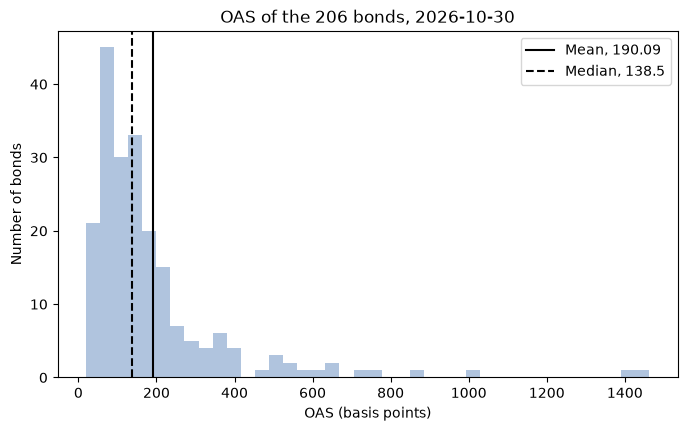

In [53]:
oas_mean = book['oas'].mean()
oas_median = book['oas'].median()

answer_6_1 = (book['oas'] > oas_mean).sum()
print('Bonds with an OAS above the mean:', answer_6_1, 'of', len(book))

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(book['oas'], bins=40, color='lightsteelblue')

# axvline() draws a vertical line
ax.axvline(oas_mean, color='black', label='Mean, ' + str(round(oas_mean, 2)))
ax.axvline(oas_median, color='black', linestyle='--', label='Median, ' + str(oas_median))

ax.legend()
ax.set_title('OAS of the 206 bonds, 2026-10-30')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Number of bonds')

plt.show()

* The crowd is on the left, below about 300 basis points, and a thin tail runs out to 1,463.
* 61 of the 206 bonds are above the mean of 190.09. If the column were even, about half would be. The tail pulls the mean up past most of the bonds.

In [54]:
check('Question 6.1', answer_6_1, '89479a1fc837')

Question 6.1: correct


### 6.2 The IQR rule

Q. Apply the IQR rule to the OAS. Print the two quartiles, the IQR, and the two limits, and draw a box plot of the column. Store the upper limit, rounded to 3 decimal places, in **answer_6_2a** and the number of bonds above it in **answer_6_2b**.

First quartile: 81.5  third quartile: 208.75  IQR: 127.25
Lower limit: -109.375  upper limit: 399.625
Bonds below the lower limit: 0
Bonds above the upper limit: 18


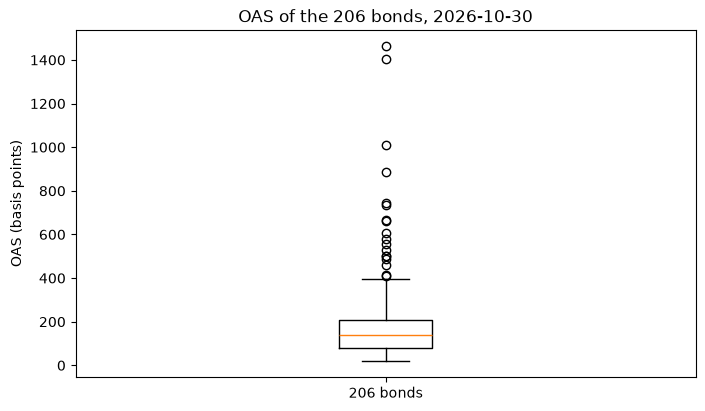

In [55]:
# the quartiles, the IQR, and the limits one and a half IQRs beyond each quartile
q1 = book['oas'].quantile(0.25)
q3 = book['oas'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

wide = book['oas'] > upper_limit

answer_6_2a = upper_limit
answer_6_2b = wide.sum()

print('First quartile:', q1, ' third quartile:', q3, ' IQR:', iqr)
print('Lower limit:', lower_limit, ' upper limit:', upper_limit)
print('Bonds below the lower limit:', (book['oas'] < lower_limit).sum())
print('Bonds above the upper limit:', answer_6_2b)

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() takes one column. tick_labels= names the box.
ax.boxplot(book['oas'], tick_labels=['206 bonds'])

ax.set_title('OAS of the 206 bonds, 2026-10-30')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The middle half of the bonds lies between 81.5 and 208.75 basis points, an IQR of 127.25. The upper limit is 399.625.
* 18 bonds are above it, the circles on the chart. The lower limit is -109.375, below zero, and nothing is under it.
* In Excel: `=QUARTILE.INC(M2:M207, 3) + 1.5 * (QUARTILE.INC(M2:M207, 3) - QUARTILE.INC(M2:M207, 1))` returns the upper limit, 399.625.

In [56]:
check('Question 6.2 upper limit', answer_6_2a, '6b59303d0caa', places=3)
check('Question 6.2 bonds flagged', answer_6_2b, 'e0d3e92c93af')

Question 6.2 upper limit: correct
Question 6.2 bonds flagged: correct


### 6.3 Errors or real bonds?

Q. Show the flagged bonds, widest first, with their rating, coupon, price, yield, and OAS. Are they errors or real bonds? Give the evidence from the other columns, and state your decision.

Store the flagged bonds' share of the book's market value, in percent rounded to 2 decimal places, in **answer_6_3**.

In [57]:
answer_6_3 = round(book.loc[wide, 'market_value'].sum() / book['market_value'].sum() * 100, 2)
print('Market value of the flagged bonds:', book.loc[wide, 'market_value'].sum(), 'dollars')
print('Share of the book:', answer_6_3, 'percent')
print('Scores of the flagged bonds: from', book.loc[wide, 'score'].min(), 'to', book.loc[wide, 'score'].max())

# the yield less the OAS is roughly the Treasury yield the bond is measured against
base = book['yield_pct'] - book['oas'] / 100
print('Yield less OAS, flagged bonds: from', round(base[wide].min(), 3), 'to', round(base[wide].max(), 3), 'percent')
print('Yield less OAS, other bonds:   from', round(base[~wide].min(), 3), 'to', round(base[~wide].max(), 3), 'percent')

book.loc[wide, ['cusip', 'ticker', 'rating', 'coupon', 'price', 'yield_pct', 'oas']].sort_values('oas', ascending=False)

Market value of the flagged bonds: 38858755.0 dollars
Share of the book: 7.62 percent
Scores of the flagged bonds: from 14 to 18
Yield less OAS, flagged bonds: from 3.731 to 4.584 percent
Yield less OAS, other bonds:   from 3.68 to 4.585 percent


,cusip,ticker,rating,coupon,price,yield_pct,oas
68,99069RAC4,FESR,CCC+,10.750,88.780,18.415,1463
17,99009JAA9,CLDB,B,9.500,63.522,18.300,1403
135,99038MAF6,PRAN,CCC+,11.000,75.387,14.664,1008
134,99038MAE9,PRAN,CCC+,10.875,88.883,13.116,884
115,99066OAD2,NEVN,B-,10.625,92.637,11.826,744
133,99038MAH2,PRAN,CCC+,11.000,99.320,11.272,736
114,99066OAB6,NEVN,B-,11.000,99.844,11.021,666
74,99088KAH5,GALX,B-,9.250,88.521,11.021,662
197,99036KAA3,XANL,CCC,10.625,101.346,10.389,607
69,99069RAD2,FESR,CCC+,8.875,89.803,10.259,580


* All 18 have a score from 14 to 18, which is B+ or lower: every one is High Yield. The widest are FESR at 1,463 basis points and CLDB at 1,403, with yields of 18.415 and 18.3 percent.
* The columns tell one story. A low rating, a wide spread, a high yield, and for most of them a high coupon or a low price.
* The yield less the OAS of the 18 runs from 3.731 to 4.584 percent, inside the band of 3.68 to 4.585 percent that the other 188 bonds occupy. The wrong prices of question 3.6 broke a relationship between columns. These bonds keep every one.

**Decision 7.** Keep all 18. They are real bonds with wide spreads, and they stay in every number. They are 38,858,755.0 dollars of market value, 7.62 percent of the book.

* Two of the 18 were corrected earlier in another column: XANL `99036KAA3` had a price in the wrong units and SKEN `99046UAD3` the wrong maturity. A bond can have an error in one column and a real extreme in another, and each column is judged on its own evidence.

In [58]:
check('Question 6.3', answer_6_3, '6ec77e85b8db', places=2)

Question 6.3: correct


**The decision the checkpoint expects.** A row is corrected if it is an error and the right value is known, flagged if it is an error and the right value is not known, and kept if it is real. No row is deleted for being far away. Test the flagged bonds against their other columns before deciding which kind they are.

### 6.4 The distribution of the price

Q. Draw a histogram of the clean price. How many bonds are priced below 100? Store the count in **answer_6_4**. Show the bond with the lowest price and the bond with the highest, and say whether either is an error.

Bonds priced below 100: 114  at 100 or above: 92


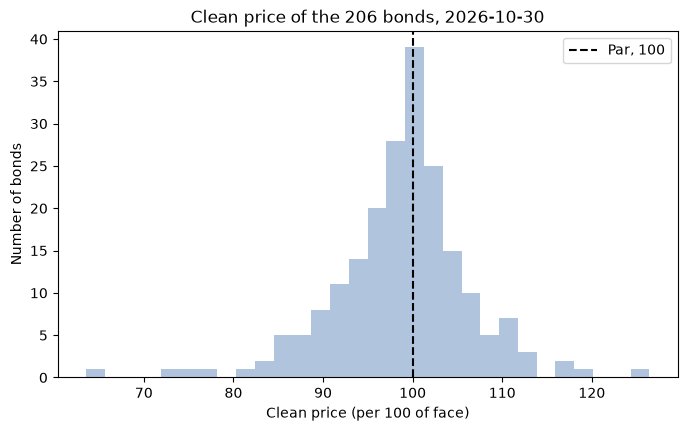

,cusip,ticker,rating,coupon,maturity,price,yield_pct,oas
17,99009JAA9,CLDB,B,9.50,2034-12-06,63.522,18.300,1403
192,99122SAE3,WYXE,BBB+,7.25,2056-07-24,126.427,5.445,86


In [59]:
answer_6_4 = (book['price'] < 100).sum()
print('Bonds priced below 100:', answer_6_4, ' at 100 or above:', (book['price'] >= 100).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(book['price'], bins=30, color='lightsteelblue')

# a line at par
ax.axvline(100, color='black', linestyle='--', label='Par, 100')

ax.legend()
ax.set_title('Clean price of the 206 bonds, 2026-10-30')
ax.set_xlabel('Clean price (per 100 of face)')
ax.set_ylabel('Number of bonds')

plt.show()

# idxmin() and idxmax() return the row labels of the lowest and the highest price
book.loc[[book['price'].idxmin(), book['price'].idxmax()], ['cusip', 'ticker', 'rating', 'coupon', 'maturity', 'price', 'yield_pct', 'oas']]

* 114 bonds are priced below 100 and 92 at 100 or above. The prices crowd around par, with a tail on the left, the negative skew of question 5.3.
* The lowest price is 63.522, for CLDB `99009JAA9`, a B bond with a 9.5 percent coupon, a yield of 18.3 percent, and an OAS of 1,403 basis points. It is one of the 18 wide bonds: a low price and a wide spread are the same fact seen twice.
* The highest price is 126.427, for WYXE `99122SAE3`, a BBB+ bond with a 7.25 percent coupon that matures in 2056 and yields 5.445 percent: a long bond with a coupon well above its yield.
* Neither is an error. Both tie out to their market value in question 4.1.

In [60]:
check('Question 6.4', answer_6_4, 'afae190215ba')

Question 6.4: correct


### 6.5 The size of the positions

Q. Draw a histogram of the market value of the positions, in millions of dollars. Which is the largest position, and what share of the book is it? Store that share, in percent rounded to 2 decimal places, in **answer_6_5**. Does the IQR rule flag any position as large?

Smallest position: 0.21 million dollars
Largest position: 5.44 million dollars, 1.07 percent of the book
Median position: 2.33  mean: 2.48 million dollars
IQR upper limit: 7.37 million dollars. Positions above it: 0


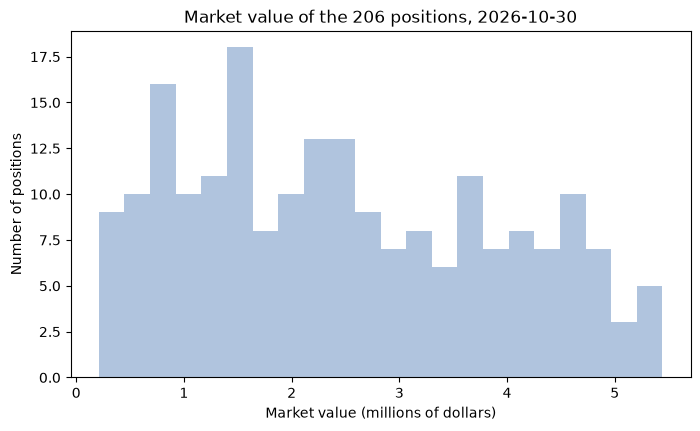

,cusip,ticker,issuer,par_held,market_value
61,99021VAC2,FESA,Feskundra Systems,5000000,5442600.0
105,99076YAC0,LORN,Lorvebran Paper,4750000,5423550.0
183,99024YAE9,VYRE,Vyrerone Metals,4750000,5382747.5


In [61]:
# market value in millions of dollars
value_mm = book['market_value'] / 1_000_000

answer_6_5 = round(book['market_value'].max() / book['market_value'].sum() * 100, 2)
print('Smallest position:', round(value_mm.min(), 2), 'million dollars')
print('Largest position:', round(value_mm.max(), 2), 'million dollars,', answer_6_5, 'percent of the book')
print('Median position:', round(value_mm.median(), 2), ' mean:', round(value_mm.mean(), 2), 'million dollars')

# the IQR upper limit for position size
size_limit = value_mm.quantile(0.75) + 1.5 * (value_mm.quantile(0.75) - value_mm.quantile(0.25))
print('IQR upper limit:', round(size_limit, 2), 'million dollars. Positions above it:', (value_mm > size_limit).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(value_mm, bins=22, color='lightsteelblue')

ax.set_title('Market value of the 206 positions, 2026-10-30')
ax.set_xlabel('Market value (millions of dollars)')
ax.set_ylabel('Number of positions')

plt.show()

# nlargest(n, column) gives the n rows with the largest values
book.nlargest(3, 'market_value')[['cusip', 'ticker', 'issuer', 'par_held', 'market_value']]

* Positions run from 0.21 to 5.44 million dollars. The median is 2.33 million and the mean 2.48 million, close together, as the skew of 0.28 said.
* The largest position is FESA `99021VAC2`, 5,442,600 dollars on 5,000,000 of face, which is 1.07 percent of the book. The next two are 5,423,550 and 5,382,747.5.
* The IQR upper limit is 7.37 million dollars and no position is above it. By position size the book has no outlier.

In [62]:
check('Question 6.5', answer_6_5, 'b905ffad5df0', places=2)

Question 6.5: correct


## 7 Two or more columns

### 7.1 Correlations

Q. Produce the correlation table of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `score`, rounded to 2 decimal places, and draw it as a heatmap with the number in each cell. Store the correlation of OAS and score, rounded to 2 decimal places, in **answer_7_1**.

A good answer names the strongest pair, a pair near zero, and says what the sign of the OAS and score figure means given how the score is built.

           coupon  price  yield_pct   oas  duration  score
coupon       1.00   0.25       0.76  0.76     -0.05   0.69
price        0.25   1.00      -0.35 -0.33     -0.17  -0.19
yield_pct    0.76  -0.35       1.00  0.99      0.01   0.75
oas          0.76  -0.33       0.99  1.00     -0.11   0.76
duration    -0.05  -0.17       0.01 -0.11      1.00  -0.12
score        0.69  -0.19       0.75  0.76     -0.12   1.00
Correlation of OAS and score: 0.76


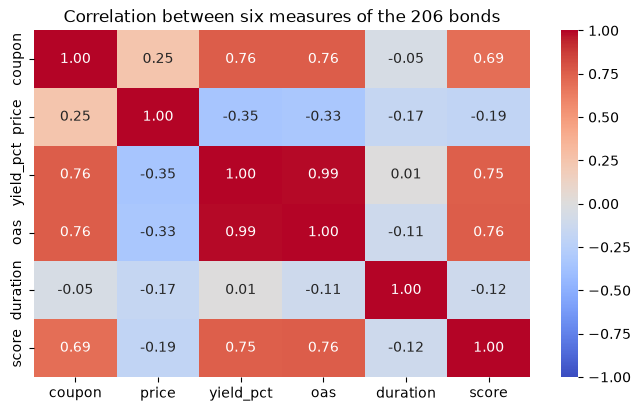

In [63]:
# corr() on a table gives the correlation of every pair of its columns
corr_table = book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'score']].corr()

answer_7_1 = round(corr_table.loc['oas', 'score'], 2)
print(corr_table.round(2))
print('Correlation of OAS and score:', answer_7_1)

fig, ax = plt.subplots(figsize=(8, 4.5))

# annot=True writes the number in each cell. vmin and vmax fix the ends of the colour scale, so 0 is in the middle.
sns.heatmap(corr_table, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation between six measures of the 206 bonds')

plt.show()

* The strongest pair is yield and OAS, 0.99: across one file on one date they are almost one column.
* OAS and score have a correlation of 0.76. The score rises as the rating falls, so a positive figure says that lower-rated bonds in this file have wider spreads. The coupon has 0.76 with the OAS and 0.69 with the score.
* Duration is near zero against every other column: -0.11 with the OAS and 0.01 with the yield. Question 7.2 looks inside the second figure.
* Price is -0.35 with the yield and -0.33 with the OAS.

In [64]:
check('Question 7.1', answer_7_1, '04220a7550f8', places=2)

Question 7.1: correct


### 7.2 Yield against duration, by grade

Q. Draw a scatter plot of yield against duration, with the two grades in different colours. Then work out the correlation of duration and yield, the two columns on the chart, for the whole book and within each grade. Store the Investment Grade figure, rounded to 2 decimal places, in **answer_7_2**.

A good answer says what the whole-book figure hides.

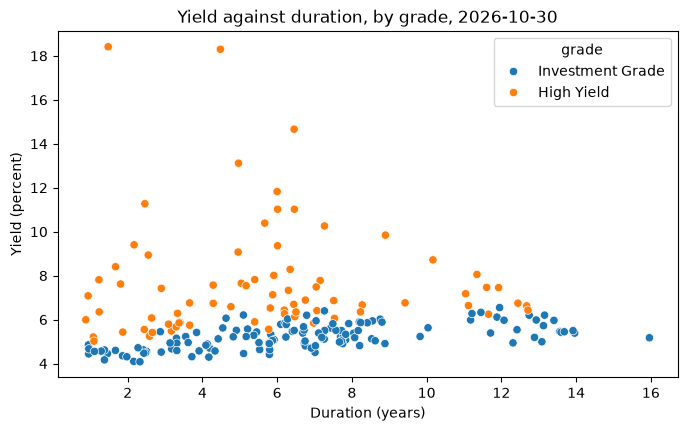

All 206 bonds: 0.01
Investment Grade - 130 bonds: 0.61
   yields from 4.081 to 6.546 percent
High Yield - 76 bonds: -0.01
   yields from 5.02 to 18.415 percent


In [65]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# hue= names the column that sets the colour of each point
sns.scatterplot(data=book, x='duration', y='yield_pct', hue='grade', ax=ax)

ax.set_title('Yield against duration, by grade, 2026-10-30')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('Yield (percent)')

plt.show()

print('All 206 bonds:', round(book['duration'].corr(book['yield_pct']), 2))

# the same correlation on the bonds of one grade at a time
for grade in ['Investment Grade', 'High Yield']:
    part = book[book['grade'] == grade]
    print(grade, '-', len(part), 'bonds:', round(part['duration'].corr(part['yield_pct']), 2))
    print('   yields from', part['yield_pct'].min(), 'to', part['yield_pct'].max(), 'percent')

investment_grade = book[book['grade'] == 'Investment Grade']
answer_7_2 = round(investment_grade['duration'].corr(investment_grade['yield_pct']), 2)

* On the chart the Investment Grade bonds lie in a narrow band along the bottom, from 4.081 to 6.546 percent, and the band rises to the right. The High Yield bonds are spread above them, from 5.02 to 18.415 percent, and most of the highest yields have a duration under 7 years.
* Duration and yield have a correlation of 0.01 over the whole book, 0.61 across the 130 Investment Grade bonds, and -0.01 across the 76 High Yield bonds.
* The whole-book figure hides a clear tilt within Investment Grade, where the longer bonds in this file have the higher yields. Two groups with different patterns, put in one cloud, show no pattern.
* This describes one invented file on one date. It is not a statement about what any bond should yield.

In [66]:
check('Question 7.2', answer_7_2, '187b8b448dbc', places=2)

Question 7.2: correct


### 7.3 OAS by rating bucket

Q. Show the number of bonds and the median, lowest, and highest OAS of each rating bucket, in credit order, and draw the median OAS by bucket as a bar chart. Store the median OAS of the BBB bucket, rounded to 1 decimal place, in **answer_7_3**.

        count  median  min   max
bucket                          
AAA         3    20.0   19    23
AA          9    38.0   22    59
A          58    74.5   42   152
BBB        60   132.5   64   204
BB         50   211.5  131   381
B          20   437.5  229  1403
CCC         6   810.0  580  1463


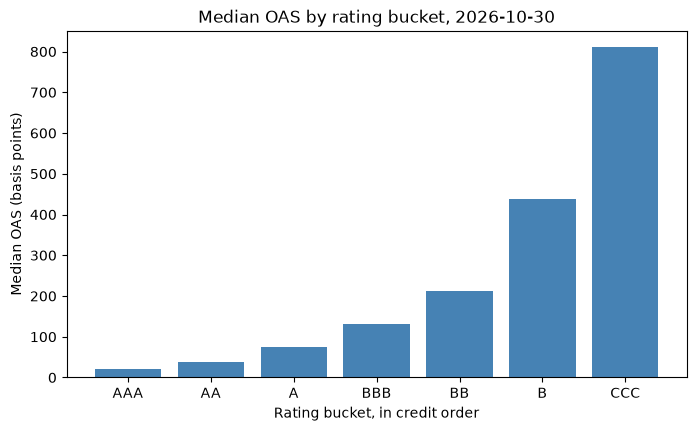

In [67]:
# the buckets in credit order, from the rating scale sorted by score
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

# four summaries of the OAS for each bucket, put in credit order with .loc
by_bucket = book.groupby('bucket')['oas'].agg(['count', 'median', 'min', 'max']).loc[bucket_order]
print(by_bucket)

answer_7_3 = by_bucket.loc['BBB', 'median']

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(by_bucket.index, by_bucket['median'], color='steelblue')

ax.set_title('Median OAS by rating bucket, 2026-10-30')
ax.set_xlabel('Rating bucket, in credit order')
ax.set_ylabel('Median OAS (basis points)')

plt.show()

* The median OAS rises at every step down the scale: 20 basis points for AAA, 38 for AA, 74.5 for A, 132.5 for BBB, 211.5 for BB, 437.5 for B, and 810 for CCC.
* The steps get larger. From A to BBB is 58 basis points, and from B to CCC is 372.5.
* The ranges overlap. The BBB bonds run from 64 to 204 basis points and the BB bonds from 131 to 381, so the widest BBB bond is wider than the tightest BB bond.
* The CCC median is over 6 bonds and the AAA median over 3. A median of so few bonds describes those bonds and little else.

In [68]:
check('Question 7.3', answer_7_3, '132f7a29d73f', places=1)

Question 7.3: correct


### 7.4 OAS by grade

Q. Compare the OAS of the two grades with a box plot, one box for each grade. Print the number of bonds and the median of each. Store the High Yield median less the Investment Grade median, rounded to 1 decimal place, in **answer_7_4**.

Investment Grade - bonds: 130  median: 89.0  mean: 98.45  widest: 204
High Yield       - bonds: 76  median: 259.0  mean: 346.86  widest: 1463
High Yield median less Investment Grade median: 170.0 basis points


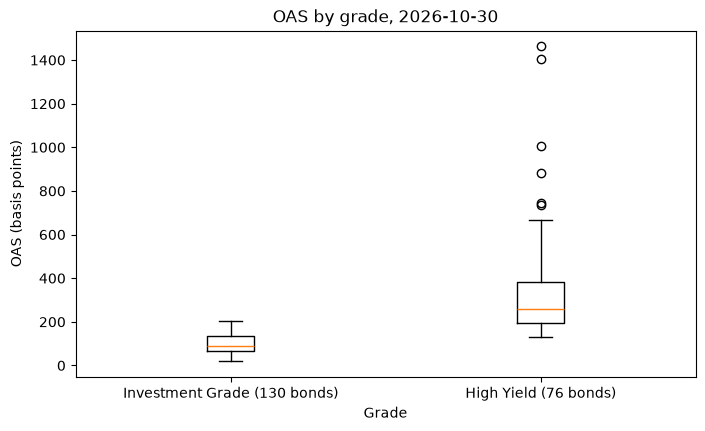

In [69]:
# the OAS of each grade
ig_oas = book.loc[book['grade'] == 'Investment Grade', 'oas']
hy_oas = book.loc[book['grade'] == 'High Yield', 'oas']

print('Investment Grade - bonds:', len(ig_oas), ' median:', ig_oas.median(), ' mean:', round(ig_oas.mean(), 2), ' widest:', ig_oas.max())
print('High Yield       - bonds:', len(hy_oas), ' median:', hy_oas.median(), ' mean:', round(hy_oas.mean(), 2), ' widest:', hy_oas.max())

answer_7_4 = hy_oas.median() - ig_oas.median()
print('High Yield median less Investment Grade median:', answer_7_4, 'basis points')

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() draws one box for each group in the list. tick_labels= names the boxes.
ax.boxplot([ig_oas, hy_oas], tick_labels=['Investment Grade (130 bonds)', 'High Yield (76 bonds)'])

ax.set_title('OAS by grade, 2026-10-30')
ax.set_xlabel('Grade')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The median OAS is 89.0 basis points for the 130 Investment Grade bonds and 259.0 for the 76 High Yield bonds, a difference of 170.0.
* The means are further apart, 98.45 and 346.86. The Investment Grade mean is close to its median, and the High Yield mean is 87.86 above its median: the tail of the whole book is the tail of the High Yield bonds.
* The widest Investment Grade bond is at 204 basis points, below the High Yield median. The Investment Grade box is short and flat beside the High Yield box, and the High Yield box has circles above its whisker within its own group.

In [70]:
check('Question 7.4', answer_7_4, '597d0edf0e6a', places=1)

Question 7.4: correct


### 7.5 Sector by grade

Q. Build a pivot table of market value, in millions of dollars, with the sectors down the side and the two grades across the top, and draw it as a heatmap with the number in each cell. Check that the cells add up to the market value of the book. Store the name of the sector with the most High Yield market value in **answer_7_5**.

grade           Investment Grade  High Yield
sector                                      
Consumer                   34.92       17.98
Energy                     32.13        7.21
Financials                 49.98       19.98
Health Care                23.58       12.15
Industrials                33.05       17.24
Materials                  36.18       36.93
Technology                 24.92       10.79
Telecom                    34.69       30.56
Transportation             38.97       21.06
Utilities                  23.24        4.35
Sum of the cells: 509.93 million dollars
Sector with the most High Yield market value: Materials


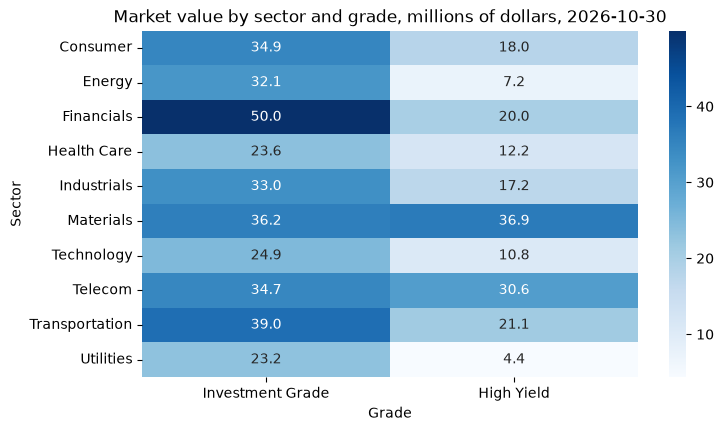

In [71]:
# sectors down the side, grades across the top, the sum of market value in each cell, in millions of dollars
sector_by_grade = pd.pivot_table(book, values='market_value', index='sector', columns='grade',
                                 aggfunc='sum', fill_value=0) / 1_000_000

# Investment Grade first
sector_by_grade = sector_by_grade[['Investment Grade', 'High Yield']]
print(sector_by_grade.round(2))
print('Sum of the cells:', round(sector_by_grade.sum().sum(), 2), 'million dollars')

answer_7_5 = sector_by_grade['High Yield'].idxmax()
print('Sector with the most High Yield market value:', answer_7_5)

fig, ax = plt.subplots(figsize=(8, 4.5))

# fmt='.1f' shows one decimal place. Blues runs from white for the lowest value to dark blue for the highest.
sns.heatmap(sector_by_grade, annot=True, fmt='.1f', cmap='Blues', ax=ax)

ax.set_title('Market value by sector and grade, millions of dollars, 2026-10-30')
ax.set_xlabel('Grade')
ax.set_ylabel('Sector')

plt.show()

* The 20 cells add up to 509.93 million dollars, the market value of the book.
* The largest cell is Investment Grade Financials, 49.98 million dollars. The smallest is High Yield Utilities, 4.35 million.
* Materials has the most High Yield market value, 36.93 million, against 36.18 million of Investment Grade. It is the only sector where the High Yield figure is the larger of the two. Telecom is the next closest, with 30.56 against 34.69.
* In Energy and Utilities the High Yield figure is under a quarter of the Investment Grade one: 7.21 against 32.13, and 4.35 against 23.24.

In [72]:
check('Question 7.5', answer_7_5, 'a49b15eabb0d')

Question 7.5: correct


## 8 The desk's questions

The third sitting starts here. These are the questions the portfolio manager will ask. Each answer is a table or a figure with its unit. Weights are percent of the book's market value unless the question says otherwise.

### 8.1 Value and weight by sector

Q. Add a `weight_pct` column to `book`: each bond's market value as a percent of the book's. Then show, for each sector, the number of bonds, the market value, and the weight, largest weight first. Check that the weights add up to 100. Store the weight of the largest sector, rounded to 2 decimal places, in **answer_8_1**.

In [73]:
total_value = book['market_value'].sum()

# each bond's share of the book, in percent
book['weight_pct'] = book['market_value'] / total_value * 100
print('Sum of the weights:', round(book['weight_pct'].sum(), 2))

# one row per sector: its bonds, their market value, and their weight
by_sector = book.groupby('sector').agg(
    bonds=('cusip', 'count'),
    market_value=('market_value', 'sum'),
    weight_pct=('weight_pct', 'sum'),
)
by_sector = by_sector.sort_values('weight_pct', ascending=False)
print(by_sector.round(2))

answer_8_1 = round(by_sector['weight_pct'].max(), 2)
print('Three largest sectors together:', round(by_sector['weight_pct'].head(3).sum(), 2), 'percent')

Sum of the weights: 100.0
                bonds  market_value  weight_pct
sector                                         
Materials          27    73113917.5       14.34
Financials         27    69958000.0       13.72
Telecom            25    65251515.0       12.80
Transportation     22    60036355.0       11.77
Consumer           24    52902217.5       10.37
Industrials        19    50287460.0        9.86
Energy             16    39345555.0        7.72
Health Care        18    35733470.0        7.01
Technology         14    35708670.0        7.00
Utilities          14    27591317.5        5.41
Three largest sectors together: 40.85 percent


* Materials is the largest sector, with 73,113,917.5 dollars in 27 bonds, 14.34 percent of the book. Financials is next with 13.72 percent, then Telecom with 12.80 and Transportation with 11.77.
* The three largest sectors together are 40.85 percent. The smallest is Utilities, 5.41 percent in 14 bonds.
* The order by weight is not the order by count: Technology and Utilities both have 14 bonds, with weights of 7.00 and 5.41 percent.
* In Excel: `=SUMIF(E2:E207, "Materials", S2:S207) / SUM(S2:S207) * 100` on the corrected sheet, or a pivot table with `sector` in Rows and Sum of `market_value` in Values, shown as a percent of the column total.

In [74]:
check('Question 8.1', answer_8_1, '1584a391227c', places=2)

Question 8.1: correct


### 8.2 Value and weight by rating bucket and grade

Q. Show the same three figures for each rating bucket, in credit order, and the weight of each grade. Store the High Yield weight, rounded to 2 decimal places, in **answer_8_2**.

In [75]:
by_bucket_value = book.groupby('bucket').agg(
    bonds=('cusip', 'count'),
    market_value=('market_value', 'sum'),
    weight_pct=('weight_pct', 'sum'),
).loc[bucket_order]
print(by_bucket_value.round(2))

by_grade = book.groupby('grade')['weight_pct'].sum()
print(by_grade.round(2))

answer_8_2 = round(by_grade.loc['High Yield'], 2)

        bonds  market_value  weight_pct
bucket                                 
AAA         3    12791580.0        2.51
AA          9    17032815.0        3.34
A          58   154371405.0       30.27
BBB        60   147458980.0       28.92
BB         50   117426757.5       23.03
B          20    46050397.5        9.03
CCC         6    14796542.5        2.90
grade
High Yield          34.96
Investment Grade    65.04
Name: weight_pct, dtype: float64


* The A bucket is the largest by weight, 30.27 percent, ahead of BBB with 28.92, though BBB has more bonds, 60 against 58. BB is 23.03 percent.
* The two ends are small: AAA 2.51 percent and AA 3.34, B 9.03 and CCC 2.90.
* Investment Grade is 65.04 percent of the book and High Yield 34.96 percent. By count High Yield is 76 of 206 bonds, which is 36.89 percent, a little more than its weight.

In [76]:
check('Question 8.2', answer_8_2, 'e795068963bf', places=2)

Question 8.2: correct


### 8.3 The ten largest issuers

Q. How many issuers are in the book? Which ten have the most market value, and what share of the book are the ten together? Store that share, in percent rounded to 2 decimal places, in **answer_8_3**.

In [77]:
print('Issuers in the book:', book['issuer'].nunique())

# one row per issuer: its bonds added together
by_issuer = book.groupby('issuer').agg(
    bonds=('cusip', 'count'),
    market_value=('market_value', 'sum'),
    weight_pct=('weight_pct', 'sum'),
)
top_ten = by_issuer.nlargest(10, 'market_value')
print(top_ten.round(2))

answer_8_3 = round(top_ten['weight_pct'].sum(), 2)
print('The ten together:', answer_8_3, 'percent of the book')
print('Ten issuers out of', book['issuer'].nunique(), 'is', round(10 / book['issuer'].nunique() * 100, 2), 'percent of the issuers')

Issuers in the book: 113
                     bonds  market_value  weight_pct
issuer                                              
Corvoquil Metals         4    14539015.0        2.85
Dralane Networks         3    12791580.0        2.51
Elverone Industrial      4    11372580.0        2.23
Heskundra Retail         3    11023215.0        2.16
Vraxorin Bancorp         3    10786540.0        2.12
Galvellix Paper          3    10359502.5        2.03
Grovostrin Freight       3    10080567.5        1.98
Lorvellix Energy         2     9999995.0        1.96
Krilellix Networks       3     9517337.5        1.87
Nevulex Health           5     8839500.0        1.73
The ten together: 21.44 percent of the book
Ten issuers out of 113 is 8.85 percent of the issuers


* 113 issuers. The largest is Corvoquil Metals, with 14,539,015 dollars in 4 bonds, 2.85 percent of the book. The second is Dralane Networks with 2.51 percent, and the tenth is Nevulex Health with 1.73.
* The ten together are 21.44 percent of the book. Ten issuers are 8.85 percent of the 113.
* An issuer is counted by adding its bonds. The largest single position was 1.07 percent in question 6.5, and the largest issuer is 2.85.
* All of these names are invented. The table says where the market value sits and nothing about any issuer.

In [78]:
check('Question 8.3', answer_8_3, 'ae78e0015082', places=2)

Question 8.3: correct


### 8.4 Weighted averages

Q. What are the average coupon, OAS, duration, and rating score of the book, both simple and weighted by market value? Store the weighted average OAS, rounded to 1 decimal place, in **answer_8_4a**, and the weighted average duration, rounded to 2 decimal places, in **answer_8_4b**.

In [79]:
# the weighted average: the sum of value times market value, divided by the sum of market value
for column in ['coupon', 'oas', 'duration', 'score']:
    simple = book[column].mean()
    weighted = (book[column] * book['market_value']).sum() / total_value
    print(column, '- simple:', round(simple, 2), ' weighted by market value:', round(weighted, 2))

answer_8_4a = round((book['oas'] * book['market_value']).sum() / total_value, 1)
answer_8_4b = round((book['duration'] * book['market_value']).sum() / total_value, 2)

coupon - simple: 5.96  weighted by market value: 5.96
oas - simple: 190.09  weighted by market value: 181.3
duration - simple: 6.33  weighted by market value: 6.08
score - simple: 9.39  weighted by market value: 9.22


* Coupon: 5.96 percent simple and 5.96 weighted. Position size and coupon are not related in this book.
* OAS: 190.09 basis points simple and 181.3 weighted. Duration: 6.33 years simple and 6.08 weighted. In both the weighted figure is the lower one, so the larger positions are, on balance, in bonds with tighter spreads and shorter durations than the smaller positions.
* Rating score: 9.39 simple and 9.22 weighted. Both are between 9, which is BBB, and 10, which is BBB-.
* The portfolio manager's figures are the weighted ones. A simple average answers a question about the typical bond, and a weighted average answers a question about the typical dollar.
* In Excel: `=SUMPRODUCT(M2:M207, S2:S207) / SUM(S2:S207)` for the weighted OAS, with the OAS in column M and the market value in column S.

In [80]:
check('Question 8.4 weighted OAS', answer_8_4a, '8a4095644cb5', places=1)
check('Question 8.4 weighted duration', answer_8_4b, '96a4349ae0e9', places=2)

Question 8.4 weighted OAS: correct
Question 8.4 weighted duration: correct


### 8.5 DTS by sector

Q. A bond's contribution to the DTS of the book is its weight, as a fraction of the book, times its DTS. The contributions of all the bonds add up to the DTS of the book. Add a `dts_contribution` column to `book`. Then show, for each sector, its weight, its contribution, and its share of the book's DTS in percent, largest contribution first. Show the same for the two grades. Store the DTS of the book, rounded to 1 decimal place, in **answer_8_5**.

In [81]:
# weight_pct is in percent, so divide by 100 for the fraction
book['dts_contribution'] = book['weight_pct'] / 100 * book['dts']

book_dts = book['dts_contribution'].sum()
answer_8_5 = round(book_dts, 1)
print('DTS of the book:', answer_8_5, 'years times basis points')

# for each sector: its weight, its contribution, and its share of the book's DTS
dts_by_sector = book.groupby('sector').agg(
    weight_pct=('weight_pct', 'sum'),
    dts_contribution=('dts_contribution', 'sum'),
)
dts_by_sector['share_of_dts_pct'] = dts_by_sector['dts_contribution'] / book_dts * 100
print(dts_by_sector.sort_values('dts_contribution', ascending=False).round(2))

# the same by grade
dts_by_grade = book.groupby('grade').agg(
    weight_pct=('weight_pct', 'sum'),
    dts_contribution=('dts_contribution', 'sum'),
)
dts_by_grade['share_of_dts_pct'] = dts_by_grade['dts_contribution'] / book_dts * 100
print(dts_by_grade.round(2))

DTS of the book: 1022.3 years times basis points
                weight_pct  dts_contribution  share_of_dts_pct
sector                                                        
Financials           13.72            149.22             14.60
Industrials           9.86            141.58             13.85
Consumer             10.37            138.27             13.52
Telecom              12.80            126.57             12.38
Materials            14.34            111.05             10.86
Transportation       11.77            109.66             10.73
Energy                7.72             82.70              8.09
Technology            7.00             60.55              5.92
Utilities             5.41             55.77              5.45
Health Care           7.01             46.97              4.59
                  weight_pct  dts_contribution  share_of_dts_pct
grade                                                           
High Yield             34.96            585.70             57.29


* The DTS of the book is 1,022.3 years times basis points.
* Financials contributes the most, 149.22, which is 14.60 percent of the book's DTS on 13.72 percent of its weight. Industrials is second with 13.85 percent of the DTS on 9.86 percent of the weight, and Consumer third with 13.52 percent on 10.37.
* Materials is the largest sector by weight, 14.34 percent, and fifth by DTS, with 10.86 percent. Health Care is 7.01 percent of the weight and 4.59 percent of the DTS, the smallest share.
* By grade, High Yield is 34.96 percent of the weight and 57.29 percent of the DTS. Investment Grade is 65.04 percent of the weight and 42.71 percent of the DTS.
* A weight says where the dollars are. A DTS share says where the spread exposure is. The two tables rank the sectors differently, and both are descriptions of the book.

In [82]:
check('Question 8.5', answer_8_5, 'fec1f67c2e64', places=1)

Question 8.5: correct


### 8.6 Maturing within three years

Q. How many bonds mature within three years of the as-of date, and what share of the book are they? Count the years as the days from the as-of date to the maturity, divided by 365.25, as in notebook 10. Store the share, in percent rounded to 2 decimal places, in **answer_8_6**.

In [83]:
# a date minus a date is a length of time. .dt.days gives it as a number of days.
book['years_to_maturity'] = (book['maturity'] - book['as_of_date']).dt.days / 365.25
print('Shortest:', round(book['years_to_maturity'].min(), 2), ' longest:', round(book['years_to_maturity'].max(), 2), 'years')

within_three = book['years_to_maturity'] <= 3

answer_8_6 = round(book.loc[within_three, 'weight_pct'].sum(), 2)
print('Bonds maturing within three years:', within_three.sum())
print('Their market value:', book.loc[within_three, 'market_value'].sum(), 'dollars')
print('Share of the book:', answer_8_6, 'percent')

Shortest: 0.92  longest: 29.73 years
Bonds maturing within three years: 35
Their market value: 94510505.0 dollars
Share of the book: 18.53 percent


* The bonds have from 0.92 to 29.73 years left.
* 35 bonds mature within three years, with 94,510,505.0 dollars of market value, 18.53 percent of the book.
* The count rests on the maturity column, and one maturity was corrected in question 4.1. Left at 2019, that row would have had a negative number of years left: the shortest figure printed above would have been below zero, which is one more way the error could have been found.

In [84]:
check('Question 8.6', answer_8_6, '774008ea1242', places=2)

Question 8.6: correct


### 8.7 The book against its benchmark, by sector

The benchmark file gives each of its 821 bonds a `weight_pct`. Adding those weights within a sector gives the benchmark's sector weight. The difference, **book weight less benchmark weight**, is in percentage points.

A positive difference is called an **overweight** and a negative one an **underweight**. In this project the two words are arithmetic and nothing more: they name the sign of a subtraction. They do not say that a weight is too high or too low, and they are not a view on any sector.

The benchmark file is the September file and the book is October's. Say so wherever the comparison is reported.

Q. Show, for each sector, the book weight, the benchmark weight, and the difference, sorted by the difference. Draw the differences as a horizontal bar chart with a line at zero. Store the name of the sector with the largest positive difference in **answer_8_7a** and that difference, rounded to 2 decimal places, in **answer_8_7b**.

A good chart here says in its title which way the subtraction runs.

                book_pct  benchmark_pct  difference
sector                                             
Utilities           5.41          11.50       -6.09
Energy              7.72          11.06       -3.35
Health Care         7.01           8.04       -1.03
Industrials         9.86           9.62        0.24
Transportation     11.77          10.74        1.03
Telecom            12.80          11.70        1.09
Consumer           10.37           9.14        1.24
Technology          7.00           5.40        1.61
Materials          14.34          11.87        2.47
Financials         13.72          10.93        2.79
Sum of the book weights: 100.0  sum of the benchmark weights: 100.0
Negative differences: 3 adding up to -10.47
Positive differences: 7 adding up to 10.47
Largest positive difference: Financials 2.79 percentage points


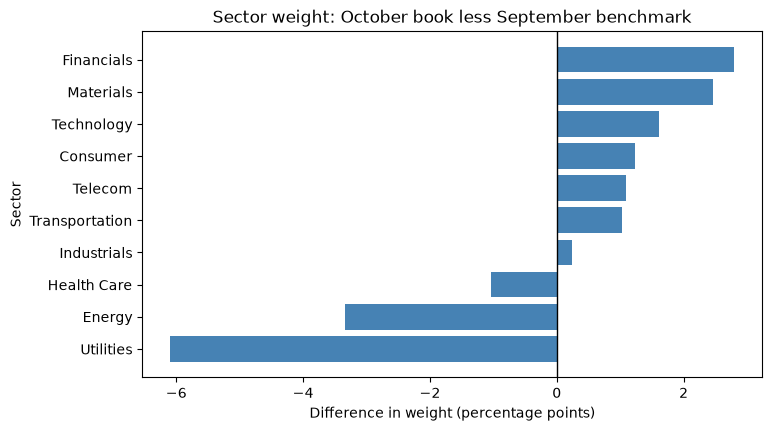

In [85]:
# the weight of each sector in the book and in the benchmark. pandas lines the two up by sector name.
sector_weights = pd.DataFrame({
    'book_pct': book.groupby('sector')['weight_pct'].sum(),
    'benchmark_pct': benchmark.groupby('sector')['weight_pct'].sum(),
})
sector_weights['difference'] = sector_weights['book_pct'] - sector_weights['benchmark_pct']

# smallest difference first, so that the largest is at the top of a horizontal bar chart
sector_weights = sector_weights.sort_values('difference')
print(sector_weights.round(2))
print('Sum of the book weights:', round(sector_weights['book_pct'].sum(), 2),
      ' sum of the benchmark weights:', round(sector_weights['benchmark_pct'].sum(), 2))

# the negative differences added together, and the positive ones
negative = sector_weights.loc[sector_weights['difference'] < 0, 'difference']
positive = sector_weights.loc[sector_weights['difference'] > 0, 'difference']
print('Negative differences:', len(negative), 'adding up to', round(negative.sum(), 2))
print('Positive differences:', len(positive), 'adding up to', round(positive.sum(), 2))

answer_8_7a = sector_weights['difference'].idxmax()
answer_8_7b = round(sector_weights['difference'].max(), 2)
print('Largest positive difference:', answer_8_7a, answer_8_7b, 'percentage points')

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.barh(sector_weights.index, sector_weights['difference'], color='steelblue')

# axvline() draws the zero line: bars to its left are sectors with less weight in the book than in the benchmark
ax.axvline(0, color='black', linewidth=1)

ax.set_title('Sector weight: October book less September benchmark')
ax.set_xlabel('Difference in weight (percentage points)')
ax.set_ylabel('Sector')

plt.show()

* Seven sectors have a positive difference and three a negative one. Both sets of weights add up to 100.0, so the positive and the negative differences cancel.
* The largest positive difference is Financials, 2.79 percentage points: 13.72 percent of the book against 10.93 percent of the benchmark. Materials is next with 2.47.
* The largest negative difference is Utilities, -6.09 percentage points: 5.41 percent of the book against 11.50 percent of the benchmark. Energy is -3.35 and Health Care -1.03.
* The Utilities bar is the longest on the chart by a wide margin: 6.09 against 3.35 for the next longest. Three negative differences that add up to -10.47 are offset by seven positive ones that add up to 10.47, none above 2.79.
* The book is as of 2026-10-30 and the benchmark as of 2026-09-30. The differences mix the desk's positions with one month of price changes in the book that the benchmark file does not have.

In [86]:
check('Question 8.7 sector', answer_8_7a, '291a7e8727cb')
check('Question 8.7 difference', answer_8_7b, '815ab0b92654', places=2)

Question 8.7 sector: correct
Question 8.7 difference: correct


### 8.8 The book against its benchmark, by rating bucket

Q. Make the same comparison by rating bucket, in credit order, and by grade. The benchmark needs the rating scale joined to it first. Draw the bucket differences as a bar chart with a line at zero and the buckets in credit order. Store the difference for the BBB bucket, rounded to 2 decimal places, in **answer_8_8**.

Benchmark rows before: 821  after: 821  with no bucket: 0
        book_pct  benchmark_pct  difference
bucket                                     
AAA         2.51           1.24        1.27
AA          3.34           3.62       -0.28
A          30.27          29.15        1.12
BBB        28.92          31.61       -2.69
BB         23.03          21.11        1.92
B           9.03          11.65       -2.62
CCC         2.90           1.62        1.28
                  book_pct  benchmark_pct  difference
grade                                                
High Yield           34.96          34.38        0.58
Investment Grade     65.04          65.62       -0.58


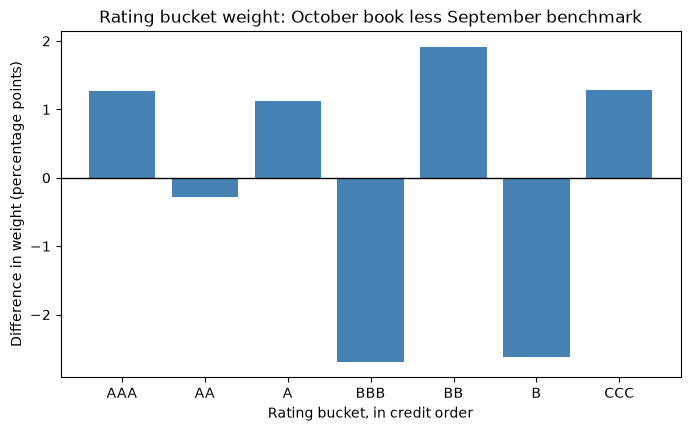

In [87]:
# the benchmark has ratings and no buckets, so look them up
benchmark_rated = pd.merge(benchmark, ratings, on='rating', how='left')
print('Benchmark rows before:', len(benchmark), ' after:', len(benchmark_rated),
      ' with no bucket:', benchmark_rated['bucket'].isna().sum())

bucket_weights = pd.DataFrame({
    'book_pct': book.groupby('bucket')['weight_pct'].sum(),
    'benchmark_pct': benchmark_rated.groupby('bucket')['weight_pct'].sum(),
}).loc[bucket_order]
bucket_weights['difference'] = bucket_weights['book_pct'] - bucket_weights['benchmark_pct']
print(bucket_weights.round(2))

grade_weights = pd.DataFrame({
    'book_pct': book.groupby('grade')['weight_pct'].sum(),
    'benchmark_pct': benchmark_rated.groupby('grade')['weight_pct'].sum(),
})
grade_weights['difference'] = grade_weights['book_pct'] - grade_weights['benchmark_pct']
print(grade_weights.round(2))

answer_8_8 = round(bucket_weights.loc['BBB', 'difference'], 2)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(bucket_weights.index, bucket_weights['difference'], color='steelblue')

# axhline() draws the zero line: bars below it are buckets with less weight in the book than in the benchmark
ax.axhline(0, color='black', linewidth=1)

ax.set_title('Rating bucket weight: October book less September benchmark')
ax.set_xlabel('Rating bucket, in credit order')
ax.set_ylabel('Difference in weight (percentage points)')

plt.show()

* The join kept all 821 benchmark bonds and every one has a bucket.
* The two largest differences are negative: BBB at -2.69 percentage points, 28.92 percent of the book against 31.61 of the benchmark, and B at -2.62, 9.03 against 11.65.
* The largest positive difference is BB, 1.92, then CCC with 1.28, AAA with 1.27, and A with 1.12. AA is -0.28.
* The signs alternate down the scale, so the grades come out close: High Yield is 34.96 percent of the book and 34.38 percent of the benchmark, a difference of 0.58 percentage points, and Investment Grade is -0.58.
* A difference of 0.58 by grade sits on top of bucket differences of up to 2.69. A comparison at one level of detail does not show what is underneath it.

In [88]:
check('Question 8.8', answer_8_8, '4f2176bc8d0c', places=2)

Question 8.8: correct


### 8.9 The bonds that carry the most DTS

Q. Which ten bonds contribute the most to the DTS of the book? Show their CUSIP, ticker, rating, OAS, duration, DTS, weight, and contribution. Store the ten bonds' share of the book's DTS, in percent rounded to 1 decimal place, in **answer_8_9**, and print their combined weight beside it.

In [89]:
# the ten rows with the largest contributions
top_dts = book.nlargest(10, 'dts_contribution')

answer_8_9 = round(top_dts['dts_contribution'].sum() / book_dts * 100, 1)
print('Share of the book DTS in the ten bonds:', answer_8_9, 'percent')
print('Their weight in the book:', round(top_dts['weight_pct'].sum(), 2), 'percent')
print(top_dts['grade'].value_counts())

top_dts[['cusip', 'ticker', 'rating', 'oas', 'duration', 'dts', 'weight_pct', 'dts_contribution']].round(2)

Share of the book DTS in the ten bonds: 22.2 percent
Their weight in the book: 6.96 percent
grade
High Yield          9
Investment Grade    1
Name: count, dtype: int64


,cusip,ticker,rating,oas,duration,dts,weight_pct,dts_contribution
115,99066OAD2,NEVN,B-,744,6.00,4462.5,0.80,35.87
134,99038MAE9,PRAN,CCC+,884,4.97,4389.9,0.77,33.63
197,99036KAA3,XANL,CCC,607,5.67,3440.5,0.66,22.84
149,99046UAA9,SKEN,B+,371,5.91,2192.6,0.98,21.56
86,99004EAB3,HLVF,B+,414,10.17,4209.1,0.49,20.83
136,99145PAA0,PRAR,B-,489,4.96,2423.0,0.85,20.68
17,99009JAA9,CLDB,B,1403,4.48,6285.4,0.30,18.67
135,99038MAF6,PRAN,CCC+,1008,6.45,6504.6,0.27,17.80
39,99002CAB9,DNMR,BB+,170,11.65,1981.2,0.89,17.61
11,99033HAF2,CLAE,BBB-,155,11.88,1841.7,0.94,17.22


* The ten bonds carry 22.2 percent of the book's DTS on 6.96 percent of its weight.
* The largest contribution is 35.87, from NEVN `99066OAD2`, a B- bond with an OAS of 744 basis points, a duration of 6.0 years, and a weight of 0.80 percent. PRAN `99038MAE9` is second with 33.63.
* 9 of the ten are High Yield and 1 is Investment Grade: CLAE `99033HAF2`, rated BBB-, with an OAS of 155 basis points and a duration of 11.88 years. DTS is a product, and a bond reaches the list through a wide spread, a long duration, a large weight, or some of each.
* CLDB `99009JAA9` has the second highest DTS of any bond in the list, 6,285.4, and is seventh by contribution, because its weight is 0.30 percent.
* The table lists where the book's DTS sits on 2026-10-30. It is not a view on any of the ten bonds.

In [90]:
check('Question 8.9', answer_8_9, 'd9214da72722', places=1)

Question 8.9: correct


### 8.10 High Yield share of bonds, by sector

Week 4 used the mean of a column of 0s and 1s as a rate. The same idea works on a bond book.

Q. Add a column `is_hy` to `book`: 1 where the grade is High Yield and 0 where it is not. For each sector, show the number of bonds, the number that are High Yield, and the High Yield share of bonds in percent, highest share first. This is a share of bonds, by count, and not a share of market value.

A rate is read with its count beside it. Store the highest share, in percent rounded to 1 decimal place, in **answer_8_10a**, and the number of bonds in that sector in **answer_8_10b**.

In [91]:
# 1 for a High Yield bond and 0 for an Investment Grade bond
book['is_hy'] = (book['grade'] == 'High Yield').astype(int)

# count() is the number of bonds, sum() the number of 1s, and mean() the share of 1s
hy_by_sector = book.groupby('sector').agg(
    bonds=('is_hy', 'count'),
    high_yield=('is_hy', 'sum'),
    hy_share_pct=('is_hy', 'mean'),
)
hy_by_sector['hy_share_pct'] = hy_by_sector['hy_share_pct'] * 100
hy_by_sector = hy_by_sector.sort_values('hy_share_pct', ascending=False)
print(hy_by_sector.round(1))

answer_8_10a = round(hy_by_sector['hy_share_pct'].iloc[0], 1)
answer_8_10b = hy_by_sector['bonds'].iloc[0]
print(f'Highest share: {hy_by_sector.index[0]}, {answer_8_10a} percent of {answer_8_10b} bonds')
print(f"Whole book: {book['is_hy'].mean() * 100:.1f} percent of {len(book)} bonds")

                bonds  high_yield  hy_share_pct
sector                                         
Telecom            25          15          60.0
Materials          27          12          44.4
Technology         14           6          42.9
Transportation     22           9          40.9
Consumer           24           9          37.5
Industrials        19           7          36.8
Financials         27           8          29.6
Health Care        18           5          27.8
Energy             16           3          18.8
Utilities          14           2          14.3
Highest share: Telecom, 60.0 percent of 25 bonds
Whole book: 36.9 percent of 206 bonds


* Telecom has the highest share: 15 of its 25 bonds are High Yield, which is 60.0 percent. Materials is next with 12 of 27, 44.4 percent, then Technology with 6 of 14, 42.9 percent.
* The lowest is Utilities, 2 of 14 bonds, 14.3 percent, and then Energy, 3 of 16, 18.8 percent.
* For the whole book the share is 36.9 percent, 76 of 206 bonds, the count of question 5.1.
* The counts matter. In a sector of 14 bonds, one bond is 7.1 percentage points of the rate, so the gap between Technology and Transportation, 42.9 against 40.9, is less than one bond's worth.
* By market value the order is different: question 7.5 found that Materials holds the most High Yield market value. A share of bonds and a share of dollars answer different questions.
* In Excel: `=COUNTIFS(E2:E207, "Telecom", V2:V207, "High Yield") / COUNTIF(E2:E207, "Telecom") * 100` on the `book` sheet of the workbook that question 9.1 writes, where the sector is in column E and the grade in column V.

In [92]:
check('Question 8.10 highest share', answer_8_10a, 'ba7b4a485ef9', places=1)
check('Question 8.10 bonds', answer_8_10b, '24e6717e072e')

Question 8.10 highest share: correct
Question 8.10 bonds: correct


## 9 The deliverables

### 9.1 The workbook

The portfolio manager reads Excel. The desk's output is a workbook.

Q. Write one Excel workbook called `project_report.xlsx` with `pd.ExcelWriter`. It has two sheets: `book`, holding the cleaned table `book` without its row labels, and `summary`, holding the sector table of question 8.1 with the sector names.

Read both sheets back from the file. Store the number of rows on the `book` sheet in **answer_9_1a** and the number of rows on the `summary` sheet in **answer_9_1b**. Test the `book` sheet you read back against the market value on the cover note with an `assert`.

Then delete the workbook, and store whether the file still exists, True or False, in **answer_9_1c**.

In [93]:
report_file = 'project_report.xlsx'

# one workbook, two sheets. index=False leaves out the row labels of book.
# the sector table keeps its labels, because they are the sector names.
with pd.ExcelWriter(report_file) as writer:
    book.to_excel(writer, sheet_name='book', index=False)
    by_sector.to_excel(writer, sheet_name='summary')

print(f'{report_file} exists: {os.path.exists(report_file)}')

# read both sheets back. dtype= keeps the CUSIP as text.
book_back = pd.read_excel(report_file, sheet_name='book', dtype={'cusip': str})
summary_back = pd.read_excel(report_file, sheet_name='summary')

answer_9_1a = len(book_back)
answer_9_1b = len(summary_back)
print(f'book sheet: {answer_9_1a} rows, {book_back.shape[1]} columns')
print(f'summary sheet: {answer_9_1b} rows, {summary_back.shape[1]} columns')

# the sheet read back must still add up to the cover note
assert abs(book_back['market_value'].sum() - expected_value) < 0.005, 'the book sheet does not match the cover note'
print(f"Market value on the book sheet: {book_back['market_value'].sum():,.2f} dollars")
print(summary_back.round(2))

# delete the workbook and confirm
os.remove(report_file)
answer_9_1c = os.path.exists(report_file)
print(f'{report_file} exists: {answer_9_1c}')

project_report.xlsx exists: True
book sheet: 206 rows, 26 columns
summary sheet: 10 rows, 4 columns
Market value on the book sheet: 509,928,477.50 dollars
           sector  bonds  market_value  weight_pct
0       Materials     27    73113917.5       14.34
1      Financials     27    69958000.0       13.72
2         Telecom     25    65251515.0       12.80
3  Transportation     22    60036355.0       11.77
4        Consumer     24    52902217.5       10.37
5     Industrials     19    50287460.0        9.86
6          Energy     16    39345555.0        7.72
7     Health Care     18    35733470.0        7.01
8      Technology     14    35708670.0        7.00
9       Utilities     14    27591317.5        5.41
project_report.xlsx exists: False


* The `book` sheet came back with 206 rows and 26 columns: the 19 of the extract and the 7 added in sections 5 and 8. Its market value is 509,928,477.50 dollars, the cover note's figure.
* The `summary` sheet came back with 10 rows, one for each sector, and 4 columns: the sector, the number of bonds, the market value, and the weight.
* The workbook holds values, not formulas. The weights on the `summary` sheet are numbers that pandas wrote.
* The file is deleted because the course removes every file a notebook writes. On a desk this is the file that would be sent.

In [94]:
check('Question 9.1 book sheet', answer_9_1a, '9d7de2b41a6a')
check('Question 9.1 summary sheet', answer_9_1b, '41c618087d66')
check('Question 9.1 file left behind', answer_9_1c, 'abfbf304f79f')

Question 9.1 book sheet: correct
Question 9.1 summary sheet: correct
Question 9.1 file left behind: correct


### 9.2 The AI-use log

Q. Fill in the log below: one row for each time you asked an AI assistant for help with this project. Say what you asked, what you accepted or rejected from the answer, and how you checked it. If you used no assistant, write `none used` in the first row. That is a valid entry.

What never goes into an AI tool, or into a cloud notebook such as Colab: client names, positions, anything from your employer, including its data, code, and documents, and credentials such as passwords and keys. This project can be done with an assistant only because every file in it is synthetic. Describe the columns and the task in your question, and keep the rows out of it. Your firm's policy comes before anything said here.

There is no check cell for this question.

An example of a filled-in log. It shows the level of detail to aim for.

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| How to test that every value in a text column is exactly nine capital letters or digits | Accepted `.str.fullmatch()` with the pattern `[A-Z0-9]{9}`. Rejected the first suggestion, `.str.contains()` with the same pattern, because it passes a longer value that holds nine good characters | Ran both on a typed list of four values: one good, one in lower case, one of ten characters, and one of eight |
| How to fill a missing value in one column from two other columns of the same row | Accepted `fillna()` given a column. Rejected the suggestion to fill with the column's mean | Tested the rule on the 202 rows that have an OAS before using it: it gave the value in the file every time |
| How to write two tables to two sheets of one workbook | Accepted `pd.ExcelWriter` with one `to_excel` call for each sheet | Read both sheets back and compared the row counts and the market value with the tables in the notebook |

No row of the extract was pasted into the assistant. Each question described the columns and the task.

### 9.3 The written picture of the book

Q. Write the page for the portfolio manager, in a markdown cell, in 250 to 350 words. Use this outline:

1. **The book in five numbers.** The five figures a reader needs first, each with its unit.
2. **Concentrations.** Where the market value and the DTS sit: by sector, by grade, by issuer.
3. **Data quality.** Each problem found in the extract, in how many rows, and what was done. Say what was checked and found clean.
4. **Against the benchmark.** The differences in weight by sector and by rating bucket, as numbers, and the dates of the two files.
5. **Open items.** What the operations team needs to confirm or send.

The rule, once more: **describe, do not recommend, rank, or forecast.** Every sentence says what the data shows on 2026-10-30. No sentence says that a bond, an issuer, or a sector is attractive or unattractive, what the desk should buy or sell, or what will happen next. Overweight and underweight, if you use them, mean a positive or a negative difference in weight and nothing else.

A good conclusion can be read without the notebook, has a number in almost every sentence, gives the unit of each number, and contains nothing that is not supported by a cell above it. There is no check cell for this question.

### 9.3 A model answer

**Month-end picture of the book, 2026-10-30.** All names are invented.

**The book in five numbers.** The book holds 206 bonds of 113 issuers with a market value of 509.93 million dollars on 507.25 million of face. Weighted by market value, the average OAS is 181.3 basis points, the average duration is 6.08 years, and the average rating score is 9.22, between BBB and BBB-.

**Concentrations.** Materials is the largest sector at 14.34 percent of market value, then Financials at 13.72 and Telecom at 12.80. Investment Grade is 65.04 percent and High Yield 34.96 percent. The ten largest issuers are 21.44 percent of the book and the largest position is 1.07 percent. The DTS of the book is 1,022.3 years times basis points. High Yield carries 57.29 percent of it, and the ten bonds with the largest contributions carry 22.2 percent on 6.96 percent of the weight.

**Data quality.** The extract had 209 rows against 206 in the cover note. 3 exact duplicate rows were removed. 9 sector names with the wrong case or a stray space were tidied, taking 19 sector values to 10. 2 face amounts with the wrong sign were made positive, 3 prices in the wrong units were corrected, and 1 maturity dated 2019 was replaced with the benchmark's 2029 date. 4 missing OAS values were worked out from DTS and spread duration. The corrected table matches all three control totals. Identifiers, ratings, and price dates were checked and are clean. 18 bonds flagged by the IQR rule on OAS are real and were kept.

**Against the benchmark.** The benchmark file is dated 2026-09-30. By sector, the largest positive difference in weight is Financials, 2.79 percentage points, and the largest negative is Utilities, -6.09. By rating bucket, BBB is -2.69 and BB is 1.92. High Yield is 0.58 points above the benchmark's 34.38 percent.

**Open items.** Operations to confirm the 6 corrected values and the 4 worked-out OAS values, and to say why 3 rows were sent twice. An October benchmark file is needed to compare the two on the same date.

## The report to the desk

The six fixes are the six decisions of question 4.1, and `clean_extract` in question 4.2 applies them to the file as it arrived in one call. The seventh row is the decision of question 6.3. The problems planted in the extract are listed in `data/project_answer_key.md` in the course repo, and they match the table.

| # | Finding | How it was found | Rows | What was done | Effect |
| --- | --- | --- | --- | --- | --- |
| 1 | Rows sent twice | row count against the cover note, `duplicated()` | 3 | removed the copies | market value down 6,301,370.00 dollars to the control total |
| 2 | Sector names with the wrong case or a stray space | `isin()` against the benchmark's names, `value_counts()` | 9 | tidied | 19 sector values became 10 |
| 3 | Face held with a negative sign | rule: the face held is positive | 2 | made positive | face up 6,500,000 dollars to the control total |
| 4 | Prices in the wrong units | rule: market value equals face times price plus accrued | 3 | multiplied or divided by 100 | all 206 rows tie out |
| 5 | Maturity before the as-of date | rule: the maturity is after the as-of date | 1 | replaced with the benchmark's maturity | earliest maturity 2027-10-02 |
| 6 | OAS missing | `isna().sum()` | 4 | worked out from DTS and spread duration | mean OAS 190.21 over 202 bonds became 190.09 over 206 |
| 7 | Very wide spreads | IQR rule on OAS | 18 | kept: real bonds | none. 7.62 percent of market value |

Checked and found clean: the shape of every CUSIP, every CUSIP in the benchmark, tickers, ratings against the scale, prices, coupons, and durations above zero, face against amount outstanding, and price dates.